# IV. PREDICTIVE ANALYSIS

## Objective

Predictive analysis uses the patterns identified in the earlier stages of analysis to determine whether we can predict an important future outcome for a patient.

In Category 2 — Descriptive Analysis, we answered:

> **What is happening in the data?**

In Category 3 — Prescriptive / Multivariate Analysis, we investigated:

> **Which factors and combinations of factors are associated with important patient outcomes?**

In Category 4 — Predictive Analysis, we move one step further:

> **Can information available at the time of initial admission be used to predict which patients are at higher risk of a future outcome?**

The purpose is not simply to train a machine-learning model. The model must answer a meaningful healthcare question and build on evidence discovered during the previous analysis stages.


## Why Predictive Analysis is Important for this Hackathon

The goal of predictive analysis is not to use machine learning simply because a machine-learning model is available.

A meaningful predictive analysis should demonstrate:

- Why the dataset requires a predictive model.
- Why the selected outcome is important.
- Why the selected predictors were chosen.
- How the predictors relate to the problem identified in the earlier analysis.
- Whether the model improves our ability to identify patients at risk.
- What the model tells us that descriptive and prescriptive analysis alone could not tell us.

Therefore, our approach is:

**Previous findings → Hypothesis → Prediction target → Predictor selection → Model → Evaluation → Finding → Interpretation**

This keeps the predictive analysis connected to the clinical problem and to the results obtained in the earlier categories.

## Step 1 — Import Required Libraries

Predictive analysis requires libraries for data preparation, statistical modeling, machine learning, and model evaluation.
We import the required libraries at the beginning of the analysis so that the notebook follows a consistent and reproducible workflow.

### Why These Libraries Are Required
- `pandas` and `numpy` are used for data preparation and validation.
- `matplotlib` and `seaborn` are used to communicate model results visually.
- `ColumnTransformer` allows numeric and categorical variables to receive different preprocessing.
- `Pipeline` prevents preprocessing leakage by fitting imputation, encoding, and scaling only from the relevant training data.
- `DummyClassifier` provides a non-informative baseline that the predictive models must outperform.
- `LogisticRegression` provides an interpretable baseline clinical-risk model.
- `RandomForestClassifier` provides a nonlinear comparison model that can capture more complex relationships.
- Cross-validation is used to determine whether performance is reasonably stable across different patient subsets.

  
 **Expected outcome:** All required tools are available before we begin predictive analysis.

In [61]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES (single import cell for the notebook)
# ============================================================
# File handling
import io
from pathlib import Path

# Core data analysis
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Scikit-learn: preprocessing and pipelines
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Scikit-learn: feature selection
from sklearn.feature_selection import SelectKBest, f_classif

# Scikit-learn: data splitting and validation
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)

# Scikit-learn: models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Scikit-learn: evaluation
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

# Reproducibility (shared by all questions)
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Load the Cleaned Patient-Level Dataset

We will load `patient_master.csv`.
Each row represents one patient, allowing us to construct one prediction record per patient.

We will use the existing `cleaned_data` folder and define the data path at the beginning of the notebook.

In [65]:
# ============================================================
# 2. LOAD patient_master.csv (local folder)
# ============================================================
DATA_FOLDER = Path(
    r"C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026"
)

# Accept the file either directly in DATA_FOLDER or inside DATA_FOLDER\cleaned_data
candidate_paths = [
    DATA_FOLDER / "patient_master.csv",
    DATA_FOLDER / "cleaned_data" / "patient_master.csv",
]
MASTER_PATH = next((path for path in candidate_paths if path.is_file()), None)

if MASTER_PATH is None:
    raise FileNotFoundError(
        "patient_master.csv not found in either location:\n"
        + "\n".join(str(path) for path in candidate_paths)
    )

CLEANED_PATH = MASTER_PATH.parent
patient_master = pd.read_csv(MASTER_PATH)

print(f"Dataset loaded from: {MASTER_PATH}")
print(f"Rows: {patient_master.shape[0]:,}")
print(f"Columns: {patient_master.shape[1]:,}")

Dataset loaded from: C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026\cleaned_data\patient_master.csv
Rows: 2,008
Columns: 198


## Predictive Question 1 — Six-month readmission


## Why ask this question?

A readmission can be difficult for a patient and signals additional demand for hospital care. If we could identify higher-risk patients when they first arrive, a care team could **consider** whether a closer review or planning conversation is warranted. The question is useful because it asks for a risk estimate **before** the later outcome is known, rather than simply describing who came back afterward.

In the team's **final descriptive notebook (Q5)**, **773 of 2,008 patients (38.5%)** had a recorded readmission within six months. The **final prescriptive notebook (Q13)** found 28.3% (108/381) among patients with none of its severe-presentation, higher-BNP, and reduced-GFR signals, versus 44.7% (119/266) among those with all three. That is a useful lead, but a group difference does not tell us whether the variables can predict a new individual patient's outcome. This question tests that additional step on patients held out from model fitting.

**Counterargument:** Readmission also depends on access to care, follow-up, choices made during hospitalization, competing death, and circumstances absent from this CSV. A model might have only modest discrimination even when some descriptive group differences are large. A high-risk label is not evidence that any proposed intervention would prevent readmission.


## Question and expected result

> **Can we predict which patients are at higher risk of readmission within six months using information available at initial admission?**

**Outcome:** `re_admission_within_6_months` from the cleaned master (1 = recorded readmission, 0 = no recorded readmission). The source follows patients at 28 days, three months, and six months; the readmission time field is measured from admission. We use the existing six-month binary outcome without recalculating it from event times. Any unclear or conflicting follow-up record should be reviewed before clinical use.

**Decision time:** initial admission. The model should only receive data known at that time. Our primary feature set includes age group, gender, admission NYHA class, admission Killip grade, previously documented diabetes and chronic kidney disease, and the Charlson comorbidity score **if recorded at admission**. The source documentation places NYHA and Killip among admission baseline measures. If the team's `cci_score` was completed only later, remove it from `numeric_features` before running the model and explain that decision in the presentation.

**What we expect:** patients with more severe presenting illness or more comorbidity might have higher risk, but this is a hypothesis to test, not a result. The model earns its place only if it improves on both predicting the same overall readmission rate for everyone and a severity-only NYHA–Killip model, and its probability estimates are reasonably calibrated.

**What we learned from Category 3:** Q12 found that adding BNP to NYHA and Killip changed cross-validated ROC AUC from 0.558 to 0.548; it did **not** improve that comparison. Q14 found higher observed readmission in the CCI 3+ group (44.9%) than CCI 0–1 (35.5%). Q16 found only a small cross-validated AUC gain when diabetes, CKD, and COPD were added to CCI (0.533 to 0.540). These results motivate a cautious comparison, not a promise of a high-performing model. Q29/Q30 explored an integrated severity–BNP–renal framework. BNP and GFR are not in our **primary initial-admission model** because the cleaned master does not record a patient-level timestamp proving those particular lab values were available at the instant we are predicting. A later version can test them after the team verifies timing, using the same training-only preprocessing and a fresh evaluation plan.


## Analysis plan and why these steps matter

| Step | What we do | Why it matters |
|---|---|---|
| 1 | Load the cleaned master and check one patient per row, required columns, outcome values, missingness and known quality flags. | Prevent a broken merge or ambiguous label from quietly shaping the model. |
| 2 | Select only the seven prespecified admission variables. | Prevent information from the hospital stay or the six-month follow-up from leaking into admission predictions. |
| 3 | Reserve a stratified 25% test set before preprocessing. | Preserve an unseen group with roughly the same outcome balance for a final check. |
| 4 | Impute missing values, encode categories and scale numbers **inside** a training-only pipeline. | Avoid using the held-out patients to learn imputation values or category transformations. |
| 5 | Fit a constant-prevalence dummy, a NYHA–Killip-only logistic model, and a prespecified wider admission model. | Ask whether additional admission characteristics add value beyond both the overall readmission rate and the team's Category 3 severity framework. |
| 6 | Report test ROC AUC, average precision, Brier score, recall, precision, plots and group sizes. | Evaluate ranking, usefulness of positive alerts, probability quality, and the cost of missed cases. |

**Leakage rule:** do not include `readmission_time_days_from_admission`, other readmission windows, deaths, emergency return, discharge date/destination, length of stay, discharge medication counts, prescriptions or later labs. Their values may only be available after the admission decision. `inpatient_number` is an identifier, never a predictor. A biomarker recorded during the admission is **not automatically an arrival-time measurement**.

**Counterarguments and limits:** The dataset is from one hospital and a historical period, so a held-out random split is *internal* validation only. These records were assembled retrospectively; even for selected history fields, recording time should be checked. Six-month death can prevent readmission, so a low readmission probability need not mean a healthy outcome. There is no evidence here that using the model would change care or improve outcomes.

Dataset background: [PhysioNet heart-failure dataset](https://physionet.org/content/heart-failure-zigong/1.3/). Reporting principles: [TRIPOD+AI](https://www.tripod-statement.org/scope/).


### Step 3 — Check the outcome and selected admission fields

The master should have one record per `inpatient_number`. We stop if a required column is missing or if the outcome contains values other than 0, 1, or missing. Missing outcome rows cannot be supervised examples, so we count and exclude only those rows. Missing predictor values are handled later within the training pipeline. We display quality flags for review, but do not use them as predictors or automatically discard patients whose unrelated follow-up event has a flag.


In [66]:
# Q1 working copy — patient_master itself is never modified
df = patient_master.copy()

In [67]:
# Step 3 — Prespecify columns so a future outcome or discharge column cannot slip in.
target = "re_admission_within_6_months"
categorical_features = ["age_category", "gender", "diabetes",
                        "moderate_to_severe_chronic_kidney_disease"]
numeric_features = ["nyha_cardiac_function_classification", "killip_grade",
                    "cci_score"]
features = categorical_features + numeric_features

required_columns = ["inpatient_number", target] + features
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise KeyError(f"Missing expected master CSV columns: {missing_columns}")
if df["inpatient_number"].isna().any() or df["inpatient_number"].duplicated().any():
    raise ValueError("Expected one nonmissing, unique inpatient_number per patient.")

# Numerals stored as CSV text are accepted; unexpected labels are not guessed.
target_values = pd.to_numeric(df[target], errors="coerce")
invalid_outcome = df[target].notna() & target_values.isna()
if invalid_outcome.any() or not target_values.dropna().isin([0, 1]).all():
    raise ValueError("The six-month readmission target must contain only 0, 1, or missing.")

print(f"Patients: {len(df):,}; unique IDs: {df['inpatient_number'].nunique():,}")
print(f"Missing target: {target_values.isna().sum():,}")
print("Target counts (including missing):")
print(target_values.value_counts(dropna=False).sort_index())
print("Missing selected predictors:")
print(df[features].isna().sum().sort_values(ascending=False))

for flag in ["event_time_contradiction_flag", "event_time_missing_flag",
             "outcome_destination_flag"]:
    if flag in df.columns:
        print(f"{flag}: {df[flag].fillna(False).astype(str).str.lower().eq('true').sum():,} flagged")


Patients: 2,008; unique IDs: 2,008
Missing target: 0
Target counts (including missing):
re_admission_within_6_months
0    1235
1     773
Name: count, dtype: int64
Missing selected predictors:
cci_score                                    5
moderate_to_severe_chronic_kidney_disease    2
age_category                                 0
gender                                       0
diabetes                                     0
nyha_cardiac_function_classification         0
killip_grade                                 0
dtype: int64
event_time_contradiction_flag: 11 flagged
event_time_missing_flag: 24 flagged
outcome_destination_flag: 7 flagged


### Step 4 — Split before any learned cleaning

The six-month target is the answer we want to predict. It is never included among predictors. Stratification keeps a similar proportion of readmissions in the training and test groups. With only one hospital available, we cannot claim external validation.


In [68]:
# Step 4 — Define patient-level predictors and the outcome; hold out 25%.
observed = target_values.notna()
X = df.loc[observed, features].copy()
y = target_values.loc[observed].astype(int)

if y.nunique() != 2 or y.value_counts().min() < 4:
    raise ValueError("Both outcome classes need at least four patients for a stratified test.")

# Clean up empty CSV strings; leave statistical imputation to the training pipeline.
for column in categorical_features:
    # scikit-learn's imputer expects np.nan here, not pandas' scalar pd.NA.
    cleaned = X[column].astype("string").str.strip().replace("", pd.NA)
    X[column] = cleaned.astype(object).where(cleaned.notna(), np.nan)
for column in numeric_features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Labeled patients: {len(y):,}; readmitted: {y.sum():,} ({y.mean():.1%})")
print(f"Train: {len(y_train):,} ({y_train.mean():.1%} readmitted)")
print(f"Test:  {len(y_test):,} ({y_test.mean():.1%} readmitted)")


Labeled patients: 2,008; readmitted: 773 (38.5%)
Train: 1,506 (38.5% readmitted)
Test:  502 (38.4% readmitted)


### Step 5 — Fit the baseline and admission model

The dummy predicts the **training-set** readmission fraction for every test patient. The **severity model** uses only NYHA and Killip, matching the simplest clinical framework examined in the prescriptive notebook. The **wider admission model** adds age band, gender, diabetes, chronic kidney disease history, and CCI. Both are logistic regressions: intentionally simple enough to explain and less prone to overfitting than a large unconstrained model on about 2,000 records. All three models use the **same held-out patients**, so the comparison is fair. Median/mode imputation, one-hot encoding, and numeric scaling are learned from the training group only. We do not oversample, rebalance classes, or select a threshold from the test results because these choices can distort probability estimates or exaggerate performance.


In [69]:
# Step 5 — Pipelines keep every fitted transformation inside the train split.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessing = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
])

baseline = DummyClassifier(strategy="prior")
severity_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42)),
])
model = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42)),
])
baseline.fit(X_train, y_train)
severity_model.fit(X_train[["nyha_cardiac_function_classification", "killip_grade"]], y_train)
model.fit(X_train, y_train)
print("Constant-risk, NYHA–Killip, and wider admission models fitted on training patients only.")


Constant-risk, NYHA–Killip, and wider admission models fitted on training patients only.


### Step 6 — Evaluate once on the held-out patients

**ROC AUC** asks whether a readmitted patient tends to receive a higher score than a non-readmitted patient (0.5 is chance ranking). **Average precision** emphasizes the quality of positive alerts; compare it with readmission prevalence. **Brier score** checks probability error (smaller is better). At a prespecified **0.50** cutoff, recall tells us how many readmitted patients we identified and precision tells us how many alerts were true readmissions. A different alert threshold should be chosen later on training data based on an agreed clinical workload, never tuned on this held-out test group.


In [70]:
# Step 6 — One final test-set evaluation for each prespecified model.
baseline_prob = baseline.predict_proba(X_test)[:, 1]
severity_prob = severity_model.predict_proba(
    X_test[["nyha_cardiac_function_classification", "killip_grade"]]
)[:, 1]
model_prob = model.predict_proba(X_test)[:, 1]
model_pred = (model_prob >= 0.50).astype(int)

results = pd.DataFrame({
    "model": ["Training prevalence (dummy)", "NYHA–Killip only", "Wider admission model"],
    "test_roc_auc": [roc_auc_score(y_test, baseline_prob),
                     roc_auc_score(y_test, severity_prob),
                     roc_auc_score(y_test, model_prob)],
    "test_average_precision": [average_precision_score(y_test, baseline_prob),
                               average_precision_score(y_test, severity_prob),
                               average_precision_score(y_test, model_prob)],
    "test_brier_score_lower_is_better": [brier_score_loss(y_test, baseline_prob),
                                         brier_score_loss(y_test, severity_prob),
                                         brier_score_loss(y_test, model_prob)],
})
print(results.round(3).to_string(index=False))
print("\nReadmission precision/recall at a fixed 0.50 cutoff:")
print(classification_report(y_test, model_pred, labels=[0, 1],
                            target_names=["No readmission", "Readmission"],
                            zero_division=0))
print("Confusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(y_test, model_pred, labels=[0, 1]))


                      model  test_roc_auc  test_average_precision  test_brier_score_lower_is_better
Training prevalence (dummy)         0.500                   0.384                             0.237
           NYHA–Killip only         0.515                   0.400                             0.238
      Wider admission model         0.540                   0.429                             0.238

Readmission precision/recall at a fixed 0.50 cutoff:
                precision    recall  f1-score   support

No readmission       0.62      0.89      0.74       309
   Readmission       0.45      0.14      0.21       193

      accuracy                           0.60       502
     macro avg       0.54      0.52      0.47       502
  weighted avg       0.56      0.60      0.53       502

Confusion matrix (rows = actual, columns = predicted):
[[276  33]
 [166  27]]


### Step 7 — Show ranking, alerts, and probability calibration

The ROC and precision–recall plots show performance across possible cutoffs. The confusion matrix makes the 0.50-cutoff mistakes visible. In the last plot, compare each risk group's average predicted probability with its actual readmission rate: a well-calibrated model would lie near the diagonal. With a small held-out set, treat the bins as approximate, not proof of safety.


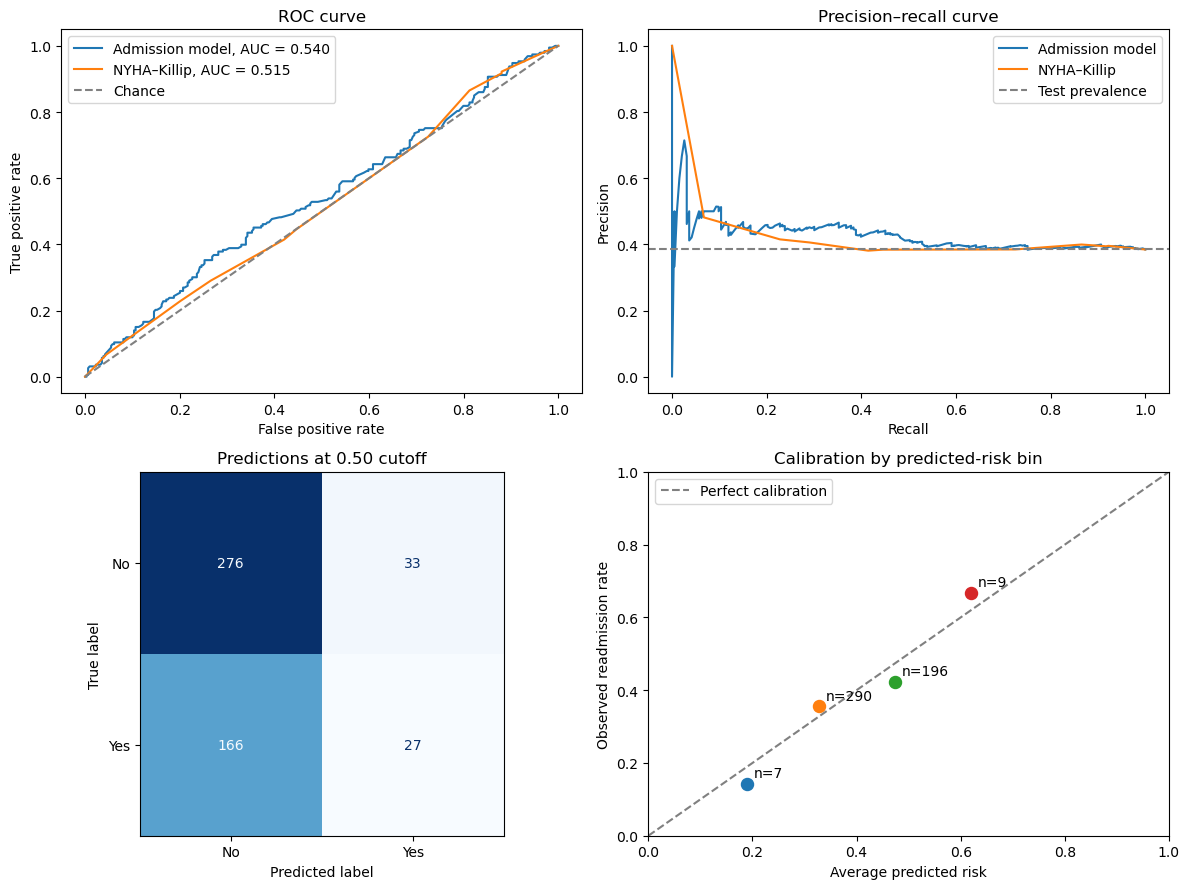

In [71]:
# Step 7 — Plots from the same untouched test patients; no refitting or tuning.
fpr, tpr, _ = roc_curve(y_test, model_prob)
severity_fpr, severity_tpr, _ = roc_curve(y_test, severity_prob)
precision, recall, _ = precision_recall_curve(y_test, model_prob)
severity_precision, severity_recall, _ = precision_recall_curve(y_test, severity_prob)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].plot(fpr, tpr, label=f"Admission model, AUC = {roc_auc_score(y_test, model_prob):.3f}")
axes[0, 0].plot(severity_fpr, severity_tpr, label=f"NYHA–Killip, AUC = {roc_auc_score(y_test, severity_prob):.3f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray", label="Chance")
axes[0, 0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve")
axes[0, 0].legend()

axes[0, 1].plot(recall, precision, label="Admission model")
axes[0, 1].plot(severity_recall, severity_precision, label="NYHA–Killip")
axes[0, 1].axhline(y_test.mean(), linestyle="--", color="gray", label="Test prevalence")
axes[0, 1].set(xlabel="Recall", ylabel="Precision", title="Precision–recall curve")
axes[0, 1].legend()

ConfusionMatrixDisplay.from_predictions(y_test, model_pred,
    display_labels=["No", "Yes"], cmap="Blues", ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("Predictions at 0.50 cutoff")

# Fixed probability intervals show their sample sizes, including empty intervals.
edges = np.linspace(0, 1, 6)
bin_index = np.minimum(np.digitize(model_prob, edges[1:], right=False), 4)
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
for index in range(5):
    members = bin_index == index
    if members.any():
        axes[1, 1].scatter(model_prob[members].mean(),
                           y_test.iloc[np.flatnonzero(members)].mean(), s=75)
        axes[1, 1].annotate(f"n={members.sum()}",
                           (model_prob[members].mean(),
                            y_test.iloc[np.flatnonzero(members)].mean()),
                           xytext=(5, 5), textcoords="offset points")
axes[1, 1].set(xlim=(0, 1), ylim=(0, 1), xlabel="Average predicted risk",
               ylabel="Observed readmission rate", title="Calibration by predicted-risk bin")
axes[1, 1].legend(loc="upper left")
plt.tight_layout()
plt.show()


### Step 8 — Interpret the model carefully

The coefficient table describes which encoded variables push the **fitted model's** score up or down, holding the other included variables fixed. It does not show causation, statistical significance, or whether acting on a feature will prevent readmission. Age and other categorical levels compare with an omitted reference level whose identity depends on encoding, so explain patterns only with that caveat.


In [72]:
# Step 8 — Inspect fitted coefficients without presenting them as interventions.
feature_names = model.named_steps["preprocessing"].get_feature_names_out()
coefficients = pd.Series(model.named_steps["classifier"].coef_[0],
                         index=feature_names).sort_values()
print("Largest negative model coefficients:")
print(coefficients.head(6).round(3).to_string())
print("\nLargest positive model coefficients:")
print(coefficients.tail(6).round(3).to_string())


Largest negative model coefficients:
categorical__age_category_29-39                              -0.628
categorical__moderate_to_severe_chronic_kidney_disease_0.0   -0.222
categorical__diabetes_0                                      -0.220
numeric__killip_grade                                        -0.122
categorical__gender_Female                                   -0.090
categorical__age_category_59-69                              -0.075

Largest positive model coefficients:
numeric__cci_score                                           0.024
categorical__diabetes_1                                      0.119
categorical__moderate_to_severe_chronic_kidney_disease_1.0   0.121
categorical__age_category_69-79                              0.219
numeric__nyha_cardiac_function_classification                0.260
categorical__age_category_21-29                              0.519


## Findings — results from the team's actual `patient_master.csv`

**Data used:** The uploaded master contained **2,008 unique patients, 198 columns, and 773 recorded six-month readmissions (38.5%)**. The outcome was recorded for everyone. We trained on **1,506** patients and evaluated once on **502** held-out patients, of whom **193 (38.4%)** were readmitted. Missing values in selected predictors were imputed using the training patients only.

**Did admission features improve prediction?** There was a small improvement in **ranking** patients, but the wider model's absolute probability error was slightly worse than the constant-risk prediction:

| Held-out test measure | Constant risk | NYHA + Killip | Wider admission model |
|---|---:|---:|---:|
| ROC AUC (higher is better) | 0.500 | 0.515 | **0.540** |
| Average precision (higher is better) | 0.384 | 0.400 | **0.429** |
| Brier score (lower is better) | **0.237** | 0.238 | 0.238 |

The wider model was slightly better at sorting patients by readmission risk, but **0.540 ROC AUC is only modestly above chance (0.500)**. The Brier scores before rounding were **0.2384** for the wider model and **0.2367** for the constant-risk baseline: this test gives no evidence of better overall probability accuracy. The dummy model's average precision equals the held-out readmission frequency (0.384).

**What happened at the chosen cutoff?** At the prespecified **0.50** probability cutoff, the model correctly flagged **27 of 193** patients who were readmitted (**recall 14.0%**). It **missed 166**, and **33 of its 60 positive alerts** were for patients who were not readmitted (**precision 45.0%**). The confusion matrix and plot show these counts. Lowering the alert threshold would identify more readmissions, but would also create more false alerts; that tradeoff needs a purpose and should be selected without tuning on this test set.

**What did the calibration plot show?** Among **290** test patients assigned an average predicted risk of **32.8%** in the 20–40% bin, **35.5%** were readmitted. Among **196** assigned an average risk of **47.3%** in the 40–60% bin, **42.3%** were readmitted. The other occupied bins had only **7** and **9** patients, so they cannot support strong conclusions about calibration. Together with the Brier result, the plot does not establish reliable probabilities.

**Connection to our earlier analysis:** Descriptive Q5 established the 38.5% readmission rate. Prescriptive Q12 found that adding BNP to NYHA and Killip did not improve its five-fold cross-validated AUC (0.558 to 0.548); Q16 found only a small AUC increase (0.533 to 0.540) from adding comorbidity flags to CCI. Our predictive analysis likewise finds limited performance on new held-out patients. These are **different evaluations and feature sets**; their AUC values should not be treated as direct like-for-like model comparisons.

**Conclusion and counterargument:** We found a weak predictive signal, **not a reliable admission screening tool**. Even a group-level relationship can provide little individual-level predictive value. Readmission depends on follow-up care and circumstances not included here, and death can prevent readmission. This is an internal random split from one hospital, not proof that the model transfers to another setting. Check predictor timestamps and test a frozen model on later or external patients before considering clinical use. Predictive association does not show that changing any one factor would prevent readmission.

**Presentation wording:** “We asked whether information available at admission could identify patients who would be readmitted within six months. We used the cleaned master, held out one quarter of the patients, and compared a wider admission model with NYHA–Killip alone and a constant-risk baseline. The wider model ranked patients a little better, with an AUC of 0.540, but it missed 166 of 193 readmissions at a 50% alert threshold and did not improve probability accuracy over the baseline. We would describe this as a weak early signal that needs better predictors and validation, not a ready-to-use hospital risk score.”


### Note before Question 2

Question 1 evaluates recorded six-month readmission in all 2,008 patients. Question 2 evaluates the 28-day target after excluding in-hospital deaths and records flagged for contradictory event timing. The horizons and eligible patient groups differ, so compare each model with its **own** baseline and report each test-set denominator. A higher score for one question does not by itself mean its model is better for the other question.


## Predictive Question 2
## Q2: Can information available at initial admission identify patients at elevated risk of readmission within 28 days?
#### Objective
The objective of this analysis is to build and evaluate a predictive model that estimates the probability that a hospitalized patient with heart failure will be readmitted within 28 days.
The model will use only information that is available at or close to the time of initial admission. This restriction is important because a model can support early care planning only when its predictors are available before the outcome occurs.
Potential uses of the model include:
- prioritizing high-risk patients for enhanced discharge planning;
- identifying patients who may benefit from earlier follow-up;
- supporting medication reconciliation and patient education;
- helping care-management teams allocate limited follow-up resources;
- providing an interpretable estimate of early readmission risk.
This model is intended as an exploratory risk-stratification tool. It is not a validated clinical decision rule and should not be used independently to make treatment decisions.

The use case matters because the official rubric gives the highest predictive score where the need for the prediction is clear and the model meaningfully improves the analysis or solves a problem.

### Hypothesis
#### Null hypothesis, H0
Admission-time clinical, demographic, renal, cardiac, laboratory, and comorbidity variables do not provide useful discrimination between patients who will and will not be readmitted within 28 days. In practical model terms, a model using these admission-time variables will not perform meaningfully better than a non-informative baseline.
#### Alternative hypothesis, H1
A combination of admission-time clinical severity, renal function, cardiac stress, vital signs, demographic characteristics, and comorbidity burden provides useful information for identifying patients at elevated risk of readmission within 28 days.
#### Primary target
`re_admission_within_28_days`
- `1` means the patient was readmitted within 28 days.
- `0` means the patient was not readmitted within 28 days.
#### Primary evaluation focus
Because early readmission may represent a minority outcome, model quality will not be judged using accuracy alone. The primary evaluation measures will be:
1. ROC-AUC, for overall discrimination.
2. Precision-recall AUC, informative when the positive class is uncommon.
3. Recall, the proportion of readmitted patients identified.
4. Precision, how many patients classified as high risk were actually readmitted.
5. Specificity, to assess false-alert burden.
6. Brier score, to assess probability accuracy.
7. Confusion matrix at a transparently selected threshold.

### Predictor Selection Strategy
Predictors are selected from clinical domains rather than by including every available column.
The selected domains are:
#### 1. Demographic profile
- `age_category`
- `gender`
- `bmi`
These variables describe baseline patient characteristics that may be related to physiological reserve, comorbidity burden, and recovery.
#### 2. Admission severity
- `nyha_cardiac_function_classification`
- `killip_grade`
NYHA and Killip represent different dimensions of heart-failure severity. Previous analysis found that NYHA was more consistently associated with readmission, while Killip may still retain supporting acute-severity information.
#### 3. Renal function
- `glomerular_filtration_rate`
- `moderate_to_severe_chronic_kidney_disease`
Measured GFR represents current renal function. The coded CKD indicator represents recorded disease history. Both are retained because they are related but not interchangeable.
#### 4. Cardiac stress and cardiac function
- `brain_natriuretic_peptide`
- `lvef`
BNP represents cardiac stress, while LVEF provides structural or functional cardiac information. BNP is expected to require transformation because of its right-skewed distribution.
#### 5. Comorbidity burden
- `cci_score`
- `diabetes`
- `congestive_heart_failure`
- `myocardial_infarction`
CCI summarizes recorded comorbidity burden. Individual conditions are included only if they are documented and sufficiently available.
#### 6. Admission vital signs
- `systolic_blood_pressure`
- `diastolic_blood_pressure`
- `pulse`
- `respiration`
Vital signs may contain information about hemodynamic or respiratory condition at admission.
#### 7. Care pathway
- `admission_way`
Admission route may provide information about the context in which the patient entered hospital care.
### Leakage Prevention
Variables recorded only after admission or after the outcome window begins will not be used.
Examples excluded from the model include:
- `dischargeday`
- `destination_discharge`
- readmission-time fields
- mortality outcomes
- later readmission outcomes
- medication counts accumulated during hospitalization
- discharge conditions
- outcome-derived flags
- any variable that directly reveals whether readmission occurred
This distinction is essential. A model can appear highly accurate if future information is included, but such a model would not be usable at initial admission.


In [9]:
# ============================================================
# VALIDATE DATASET STRUCTURE
# ============================================================
patient_id = "inpatient_number"
target = "re_admission_within_28_days"

essential_columns = [patient_id, target]
missing_essential = [c for c in essential_columns if c not in patient_master.columns]
if missing_essential:
    raise ValueError(f"Required columns are missing: {missing_essential}")

duplicate_patient_ids = patient_master[patient_id].duplicated().sum()
print(f"Unique patient IDs: {patient_master[patient_id].nunique():,}")
print(f"Duplicate patient IDs: {duplicate_patient_ids:,}")
if duplicate_patient_ids > 0:
    raise ValueError("Duplicate patient IDs were detected. Resolve the patient-level structure before modeling.")

print("\nRaw 28-day readmission values:")
print(patient_master[target].value_counts(dropna=False).sort_index())

Unique patient IDs: 2,008
Duplicate patient IDs: 0

Raw 28-day readmission values:
re_admission_within_28_days
0    1868
1     140
Name: count, dtype: int64


#### Target Validation
Before fitting a model, the outcome must be checked for:
- missing values;
- unexpected values outside 0 and 1;
- the number of readmission events;
- class imbalance;
- sufficient observations in both classes.
A model trained on an imbalanced outcome can obtain apparently high accuracy by predicting the majority class for almost every patient. Therefore, the event rate and a non-informative baseline must be reported before model performance is interpreted.

In addition, the modeling cohort excludes patients who died during the index hospitalization, since 28-day readmission is undefined for a patient who never left the hospital — coding them as a non-event would misrepresent an undefined outcome as a negative one. Rows flagged during cleaning as having contradictory event timing (`event_time_contradiction_flag`) are excluded for the same reason: their outcome labels cannot be trusted.

In [10]:
# ============================================================
# DEFINE THE MODELING COHORT AND VALIDATE THE TARGET
# ============================================================
model_df = patient_master.copy()

model_df[target] = pd.to_numeric(model_df[target], errors="coerce")
model_df = model_df[model_df[target].isin([0, 1])].copy()
model_df[target] = model_df[target].astype(int)

# Readmission is undefined for patients who died in-hospital — they
# never had the opportunity to be readmitted, so a "0" label for them
# would misrepresent them as successful non-readmissions.
# Rows flagged with event_time_contradiction_flag were already
# identified in the Cleaning Summary as having inconsistent event
# timing and are excluded from any outcome model for the same reason.
excluded_dead = model_df["outcome_during_hospitalization"] == "Dead"
excluded_contradiction = model_df["event_time_contradiction_flag"] == True

print(f"In-hospital deaths excluded: {excluded_dead.sum()}")
print(f"Contradiction-flagged rows excluded: {excluded_contradiction.sum()}")

model_df = model_df[~excluded_dead & ~excluded_contradiction].copy()

target_counts = model_df[target].value_counts().reindex([0, 1], fill_value=0)
target_rates = model_df[target].value_counts(normalize=True).reindex([0, 1], fill_value=0).mul(100)
target_summary = pd.DataFrame({"Patients": target_counts, "Percentage": target_rates})
target_summary.index = ["No 28-day readmission", "28-day readmission"]
display(target_summary.round(2))

event_count = int(model_df[target].sum())
event_rate = model_df[target].mean()
print(f"Modeling cohort: {len(model_df):,} patients")
print(f"28-day readmission events: {event_count:,}")
print(f"28-day readmission rate: {event_rate:.2%}")

if event_rate < 0.10:
    print("\nImportant: The positive class is below 10%. Accuracy will not be used as the primary model-selection metric.")

In-hospital deaths excluded: 11
Contradiction-flagged rows excluded: 11


,Patients,Percentage
No 28-day readmission,1849,93.100
28-day readmission,137,6.900


Modeling cohort: 1,986 patients
28-day readmission events: 137
28-day readmission rate: 6.90%

Important: The positive class is below 10%. Accuracy will not be used as the primary model-selection metric.


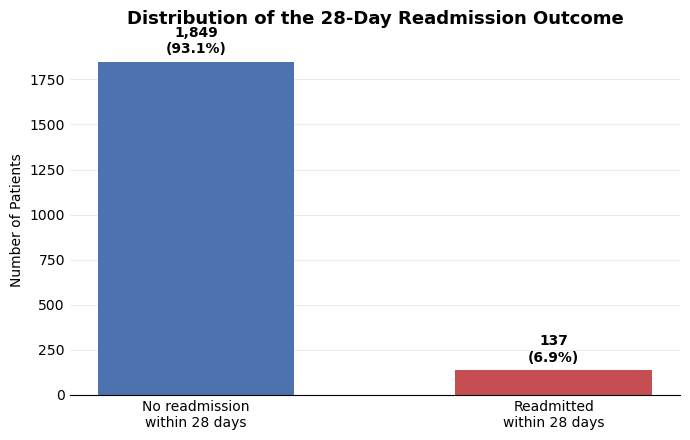

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["No readmission\nwithin 28 days", "Readmitted\nwithin 28 days"]
values = target_counts.values
bars = ax.bar(labels, values, color=["#4C72B0", "#C44E52"], width=0.55)
ax.bar_label(bars, labels=[f"{c:,}\n({r:.1f}%)" for c, r in zip(values, target_rates.values)], padding=4, fontweight="bold")
ax.set_title("Distribution of the 28-Day Readmission Outcome", fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Number of Patients")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

### Feature Eligibility Rule
A feature is eligible only if it is reasonably available at initial admission. The source dataset contains variables from several points in the hospital journey. Including post-admission information would answer a different question and could produce target leakage.
For this model:
- admission clinical measurements are eligible;
- recorded medical history is eligible;
- recorded admission severity is eligible;
- baseline laboratory tests are treated as eligible when collected during the initial assessment;
- discharge information is excluded;
- outcomes and event-time fields are excluded;
- medications accumulated over the hospitalization are excluded.
If the exact measurement timing of a laboratory variable cannot be confirmed, this uncertainty should be documented as a model limitation.

In [12]:
# Feature engineering: address collinearity found in coefficient review
model_df["pulse_pressure"] = model_df["systolic_blood_pressure"] - model_df["diastolic_blood_pressure"]
model_df["age_start"] = model_df["age_category"].str.extract(r"^(\d+)")[0].astype(float)
model_df["age_band"] = pd.cut(
    model_df["age_start"], [0, 59, 69, 79, 200], right=False,
    labels=["<59", "59-69", "69-79", "79+"]
)

numeric_candidates = [
    "bmi", "nyha_cardiac_function_classification", "killip_grade",
    "glomerular_filtration_rate", "brain_natriuretic_peptide", "lvef",
    "cci_score", "pulse_pressure", "pulse", "respiration"
]
categorical_candidates = ["age_band", "gender", "admission_way"]
# Note: diabetes, congestive_heart_failure, myocardial_infarction, and
# moderate_to_severe_chronic_kidney_disease were removed — each is
# correlated with cci_score (r=0.31-0.56), since CCI is partly built
# from these same conditions. Including both split their shared signal
# and produced clinically backwards coefficients (see coefficient
# review). cci_score alone represents comorbidity burden here.
# systolic_blood_pressure and diastolic_blood_pressure (r=0.65) were
# replaced with pulse_pressure for the same reason.

numeric_features = [c for c in numeric_candidates if c in model_df.columns]
categorical_features = [c for c in categorical_candidates if c in model_df.columns]

In [13]:
prohibited_features = {
    "re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months",
    "readmission_time_days_from_admission", "death_within_28_days", "death_within_3_months",
    "death_within_6_months", "time_of_death_days_from_admission", "dischargeday",
    "destination_discharge", "discharge_department", "outcome_during_hospitalization",
    "outcome_destination_flag", "event_time_missing_flag", "event_time_contradiction_flag",
    "total_drug_count"
}
selected_features = numeric_features + categorical_features
leakage_found = sorted(set(selected_features).intersection(prohibited_features))
if leakage_found:
    raise ValueError(f"Potential leakage fields were selected: {leakage_found}")
print("Leakage audit passed.")
print(f"Number of selected predictors: {len(selected_features)}")

Leakage audit passed.
Number of selected predictors: 13


In [14]:
feature_summary = pd.DataFrame({
    "Data_Type": model_df[selected_features].dtypes.astype(str),
    "Non_Missing": model_df[selected_features].notna().sum(),
    "Missing": model_df[selected_features].isna().sum(),
    "Missing_Percentage": model_df[selected_features].isna().mean().mul(100),
    "Unique_Values": model_df[selected_features].nunique(dropna=True)
}).sort_values("Missing_Percentage", ascending=False)
display(feature_summary.round(2))

,Data_Type,Non_Missing,Missing,Missing_Percentage,Unique_Values
lvef,float64,630,1356,68.280,66
glomerular_filtration_rate,float64,1924,62,3.120,1736
brain_natriuretic_peptide,float64,1952,34,1.710,1840
bmi,float64,1979,7,0.350,537
cci_score,float64,1981,5,0.250,7
pulse_pressure,float64,1983,3,0.150,98
pulse,float64,1985,1,0.050,122
respiration,float64,1985,1,0.050,18
nyha_cardiac_function_classification,int64,1986,0,0.000,3
killip_grade,int64,1986,0,0.000,4


### Missing-Data Strategy
Rows will not automatically be deleted merely because one predictor is missing. Deleting every incomplete row could substantially reduce the sample size, disproportionately remove clinically complex patients, reduce the number of 28-day readmission events, and make the final model less representative.
Instead: numeric variables will be imputed using the training-set median; categorical variables will be imputed using the training-set most frequent value; preprocessing will occur inside a pipeline, so imputation values are learned from training data only.

In [15]:
if "brain_natriuretic_peptide" in model_df.columns:
    model_df["log_brain_natriuretic_peptide"] = np.log1p(
        pd.to_numeric(model_df["brain_natriuretic_peptide"], errors="coerce").clip(lower=0)
    )
    numeric_features = [f for f in numeric_features if f != "brain_natriuretic_peptide"]
    numeric_features.append("log_brain_natriuretic_peptide")
    print("Raw BNP replaced by log-transformed BNP.")

Raw BNP replaced by log-transformed BNP.


In [16]:
selected_features = numeric_features + categorical_features
X = model_df[selected_features].copy()
y = model_df[target].copy()
print(f"Modeling rows: {len(X):,}")
print(f"Predictors: {X.shape[1]}")
print(f"Positive outcomes: {int(y.sum()):,}")
print(f"Negative outcomes: {int((y == 0).sum()):,}")

Modeling rows: 1,986
Predictors: 13
Positive outcomes: 137
Negative outcomes: 1,849


#### Validation Strategy
The data will be divided into a training set used for model development and cross-validation, and a test set retained for final evaluation. A stratified split is used so that the readmission proportion remains similar in both partitions.
The test set will not be used to select predictors, fit preprocessing steps, compare candidate models, or choose the classification threshold. Model selection and threshold selection will use only the training data. The untouched test set will then provide the final performance estimate.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Patients": [len(y_train), len(y_test)],
    "Readmissions": [int(y_train.sum()), int(y_test.sum())],
    "Readmission_Rate": [y_train.mean() * 100, y_test.mean() * 100]
})
display(split_summary.round(2))

,Dataset,Patients,Readmissions,Readmission_Rate
0,Training,1489,103,6.920
1,Test,497,34,6.840


In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
], remainder="drop")
print("Preprocessing pipeline created.")

Preprocessing pipeline created.


### Model Selection
Three models are evaluated.
#### 1. Dummy baseline
Provides a minimum benchmark. A useful predictive model should outperform a strategy that does not learn meaningful relationships from the predictors.
#### 2. Logistic regression
Selected as the principal interpretable model: the target is binary, predicted probabilities are required, coefficient direction can be inspected, regularization helps control model complexity, class weighting can reduce majority-class dominance.
#### 3. Random forest
Included as a nonlinear comparison: relationships may not be linear, variables may interact, threshold patterns may exist, scaling is not required. It is not automatically preferred — it must demonstrate better cross-validated performance and reasonable generalization.

In [19]:
dummy_pipeline = Pipeline([("preprocessor", preprocessor), ("model", DummyClassifier(strategy="prior"))])
logistic_pipeline = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(
    max_iter=3000, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE))])
random_forest_pipeline = Pipeline([("preprocessor", preprocessor), ("model", RandomForestClassifier(
    n_estimators=500, max_depth=6, min_samples_leaf=10, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1))])
models = {"Dummy baseline": dummy_pipeline, "Logistic regression": logistic_pipeline, "Random forest": random_forest_pipeline}
print("Candidate models created.")

Candidate models created.


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "average_precision": "average_precision",
           "balanced_accuracy": "balanced_accuracy", "recall": "recall", "precision": "precision", "f1": "f1"}
cv_results = []
for model_name, model_pipeline in models.items():
    result = cross_validate(model_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
    cv_results.append({
        "Model": model_name,
        "ROC_AUC_Mean": result["test_roc_auc"].mean(), "ROC_AUC_SD": result["test_roc_auc"].std(),
        "PR_AUC_Mean": result["test_average_precision"].mean(), "PR_AUC_SD": result["test_average_precision"].std(),
        "Balanced_Accuracy_Mean": result["test_balanced_accuracy"].mean(),
        "Recall_Mean": result["test_recall"].mean(), "Precision_Mean": result["test_precision"].mean(),
        "F1_Mean": result["test_f1"].mean()
    })
cv_comparison = pd.DataFrame(cv_results).sort_values(["PR_AUC_Mean", "ROC_AUC_Mean"], ascending=False).reset_index(drop=True)
display(cv_comparison.round(3))

,Model,ROC_AUC_Mean,ROC_AUC_SD,PR_AUC_Mean,PR_AUC_SD,Balanced_Accuracy_Mean,Recall_Mean,Precision_Mean,F1_Mean
0,Random forest,0.610,0.035,0.105,0.010,0.502,0.069,0.065,0.067
1,Logistic regression,0.533,0.040,0.104,0.032,0.547,0.494,0.084,0.143
2,Dummy baseline,0.500,0.000,0.069,0.002,0.500,0.000,0.000,0.000


### Model-Selection Rule
The preferred model should: outperform the dummy baseline; provide stronger precision-recall performance; maintain acceptable ROC-AUC; identify a useful proportion of readmitted patients; avoid an unmanageable number of false alerts; show reasonably stable performance across folds; retain interpretability where performance is similar.
A more complex model will not be selected merely because its score is marginally higher. If logistic regression and random forest perform similarly, logistic regression may be preferred because its drivers are easier to communicate and audit.

In [21]:
candidate_names = ["Logistic regression", "Random forest"]
best_model_name = cv_comparison[cv_comparison["Model"].isin(candidate_names)].sort_values(
    ["PR_AUC_Mean", "ROC_AUC_Mean"], ascending=False).iloc[0]["Model"]
best_pipeline = clone(models[best_model_name])
print(f"Selected model from cross-validation: {best_model_name}")

train_oof_probability = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
print("Training out-of-fold ROC-AUC:", round(roc_auc_score(y_train, train_oof_probability), 3))
print("Training out-of-fold PR-AUC:", round(average_precision_score(y_train, train_oof_probability), 3))

Selected model from cross-validation: Random forest
Training out-of-fold ROC-AUC: 0.611
Training out-of-fold PR-AUC: 0.095


### Classification Threshold
The default threshold of 0.50 may be inappropriate when the positive outcome is uncommon. For early readmission, failing to identify a genuinely high-risk patient may be more costly than reviewing some additional patients who will not be readmitted. However, choosing an extremely low threshold would create too many false alerts.

The threshold is selected using training-set out-of-fold predictions. The preferred threshold maximizes the F2 score, which gives recall more weight than precision — suitable when the goal is to identify as many potentially high-risk patients as practical. The selected threshold must still be interpreted alongside precision, specificity, number of patients flagged, and number of readmissions identified.

In [22]:
precision_values, recall_values, thresholds = precision_recall_curve(y_train, train_oof_probability)
precision_at_threshold = precision_values[:-1]
recall_at_threshold = recall_values[:-1]

beta = 2
beta2 = beta ** 2  # <-- was missing in the original draft

f2_scores = (
    (1 + beta2) * precision_at_threshold * recall_at_threshold
    / (beta2 * precision_at_threshold + recall_at_threshold + 1e-12)
)
best_threshold_index = np.nanargmax(f2_scores)
selected_threshold = thresholds[best_threshold_index]
print(f"Selected probability threshold: {selected_threshold:.3f}")
print(f"Training precision at threshold: {precision_at_threshold[best_threshold_index]:.3f}")
print(f"Training recall at threshold: {recall_at_threshold[best_threshold_index]:.3f}")
print(f"Training F2 at threshold: {f2_scores[best_threshold_index]:.3f}")

Selected probability threshold: 0.319
Training precision at threshold: 0.090
Training recall at threshold: 0.767
Training F2 at threshold: 0.306


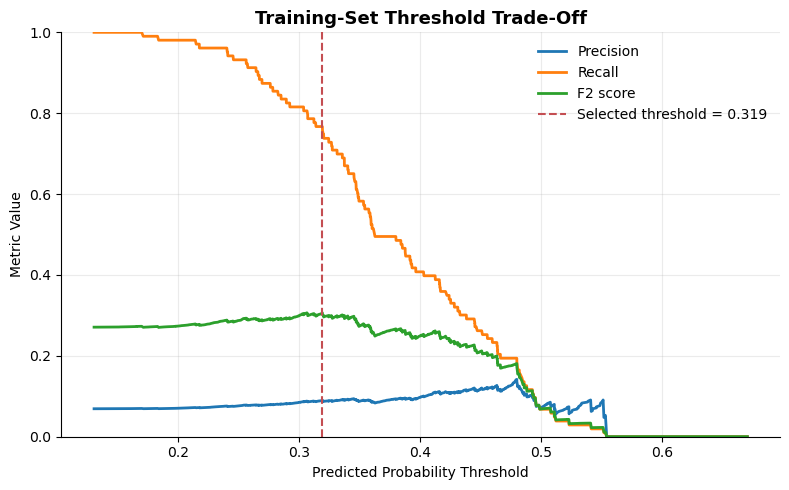

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision_at_threshold, label="Precision", linewidth=2)
ax.plot(thresholds, recall_at_threshold, label="Recall", linewidth=2)
ax.plot(thresholds, f2_scores, label="F2 score", linewidth=2)
ax.axvline(selected_threshold, color="#C44E52", linestyle="--", label=f"Selected threshold = {selected_threshold:.3f}")
ax.set_title("Training-Set Threshold Trade-Off", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Probability Threshold")
ax.set_ylabel("Metric Value")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [24]:
best_pipeline.fit(X_train, y_train)
test_probability = best_pipeline.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_prediction, labels=[0, 1]).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
negative_predictive_value = tn / (tn + fn) if (tn + fn) > 0 else np.nan

test_metrics = pd.DataFrame({
    "Metric": ["ROC-AUC", "Precision-recall AUC", "Brier score", "Accuracy", "Balanced accuracy",
               "Recall / sensitivity", "Specificity", "Precision", "Negative predictive value", "F1 score",
               "Patients flagged high risk", "Readmissions correctly identified"],
    "Value": [
        roc_auc_score(y_test, test_probability), average_precision_score(y_test, test_probability),
        brier_score_loss(y_test, test_probability), accuracy_score(y_test, test_prediction),
        balanced_accuracy_score(y_test, test_prediction), recall_score(y_test, test_prediction, zero_division=0),
        specificity, precision_score(y_test, test_prediction, zero_division=0), negative_predictive_value,
        f1_score(y_test, test_prediction, zero_division=0), int(test_prediction.sum()), int(tp)
    ]
})
display(test_metrics.round(3))
print("\nClassification report:")
print(classification_report(y_test, test_prediction, target_names=["No 28-day readmission", "28-day readmission"], zero_division=0))

,Metric,Value
0,ROC-AUC,0.619
1,Precision-recall AUC,0.163
2,Brier score,0.152
3,Accuracy,0.396
4,Balanced accuracy,0.567
5,Recall / sensitivity,0.765
6,Specificity,0.369
7,Precision,0.082
8,Negative predictive value,0.955
9,F1 score,0.148



Classification report:
                       precision    recall  f1-score   support

No 28-day readmission       0.96      0.37      0.53       463
   28-day readmission       0.08      0.76      0.15        34

             accuracy                           0.40       497
            macro avg       0.52      0.57      0.34       497
         weighted avg       0.90      0.40      0.51       497



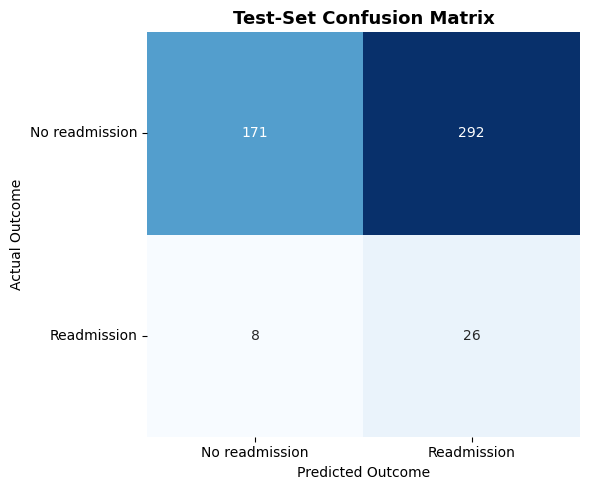

True negatives: 171
False positives: 292
False negatives: 8
True positives: 26


In [25]:
confusion = confusion_matrix(y_test, test_prediction, labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Test-Set Confusion Matrix", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Actual Outcome")
ax.set_xticklabels(["No readmission", "Readmission"])
ax.set_yticklabels(["No readmission", "Readmission"], rotation=0)
plt.tight_layout()
plt.show()
print(f"True negatives: {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives: {tp}")

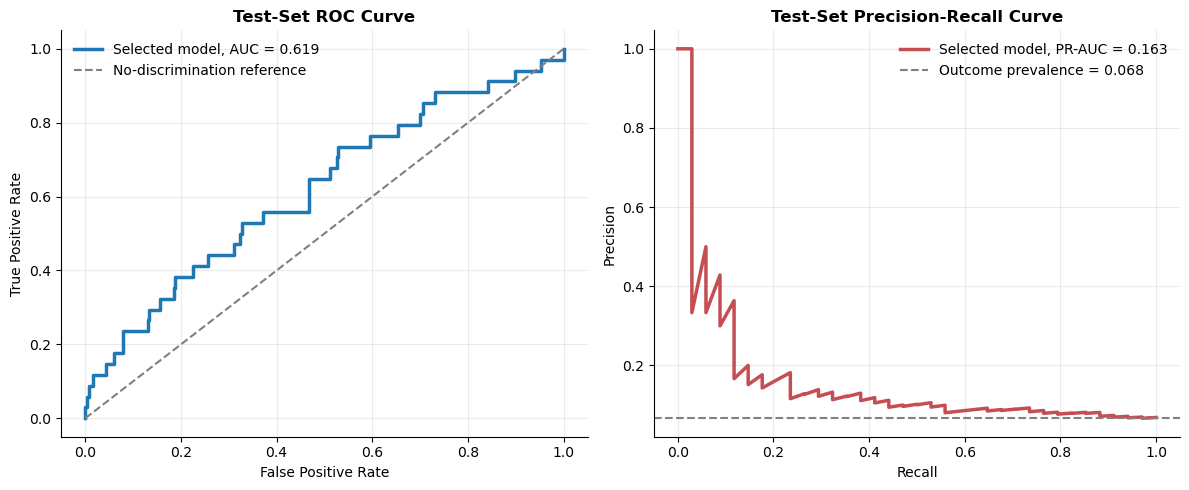

In [26]:
test_roc_auc = roc_auc_score(y_test, test_probability)
test_pr_auc = average_precision_score(y_test, test_probability)
fpr, tpr, _ = roc_curve(y_test, test_probability)
test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, test_probability)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, linewidth=2.5, label=f"Selected model, AUC = {test_roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No-discrimination reference")
axes[0].set_title("Test-Set ROC Curve", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(frameon=False)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(alpha=0.25)

axes[1].plot(test_recall_curve, test_precision_curve, linewidth=2.5, color="#C44E52", label=f"Selected model, PR-AUC = {test_pr_auc:.3f}")
axes[1].axhline(y=y_test.mean(), linestyle="--", color="gray", label=f"Outcome prevalence = {y_test.mean():.3f}")
axes[1].set_title("Test-Set Precision-Recall Curve", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Why Accuracy Is Not the Main Result
If 28-day readmission is uncommon, a model that predicts "no readmission" for every patient may achieve high overall accuracy while identifying no high-risk patients.
Therefore: accuracy is reported for completeness; balanced accuracy gives equal weight to both outcome classes; recall shows how many readmitted patients are identified; precision shows the reliability of a high-risk alert; precision-recall AUC summarizes performance for the less common positive outcome; ROC-AUC summarizes overall ranking discrimination; Brier score evaluates the accuracy of predicted probabilities.

A model should not be described as successful merely because its accuracy is high.

,Patients,Predicted_Risk,Observed_Readmission_Rate,Readmissions
risk_group,,,,
Group 1,100,0.250,0.040,4
Group 2,99,0.308,0.051,5
Group 3,99,0.355,0.061,6
Group 4,99,0.406,0.061,6
Group 5,100,0.487,0.130,13


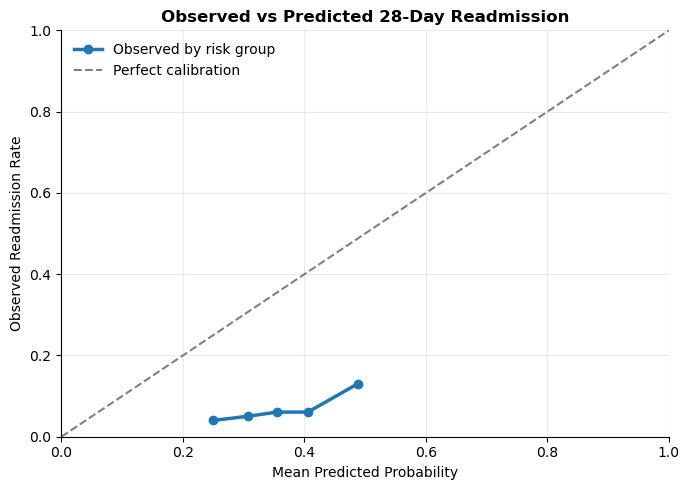

In [27]:
calibration_df = pd.DataFrame({"actual": y_test.to_numpy(), "predicted_probability": test_probability})
number_of_groups = min(5, calibration_df["predicted_probability"].nunique())
if number_of_groups >= 2:
    calibration_df["risk_group"] = pd.qcut(
        calibration_df["predicted_probability"].rank(method="first"),
        q=number_of_groups, labels=[f"Group {i + 1}" for i in range(number_of_groups)]
    )
    calibration_summary = calibration_df.groupby("risk_group", observed=True).agg(
        Patients=("actual", "size"), Predicted_Risk=("predicted_probability", "mean"),
        Observed_Readmission_Rate=("actual", "mean"), Readmissions=("actual", "sum")
    )
    display(calibration_summary.round(3))
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(calibration_summary["Predicted_Risk"], calibration_summary["Observed_Readmission_Rate"],
            marker="o", linewidth=2.5, label="Observed by risk group")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.set_title("Observed vs Predicted 28-Day Readmission", fontweight="bold")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Readmission Rate")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("Calibration grouping could not be created because the model produced too few distinct probabilities.")

In [28]:
logistic_pipeline.fit(X_train, y_train)
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_pipeline.named_steps["model"].coef_[0]
coefficient_table = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients, "Odds_Multiplier": np.exp(coefficients)})
coefficient_table["Absolute_Coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table = coefficient_table.sort_values("Absolute_Coefficient", ascending=False)
print("Largest logistic-regression coefficients. These are model associations, not causal effects.")
display(coefficient_table[["Feature", "Coefficient", "Odds_Multiplier"]].head(20).round(3))

Largest logistic-regression coefficients. These are model associations, not causal effects.


,Feature,Coefficient,Odds_Multiplier
20,categorical__age_band_<59,-0.877,0.416
21,categorical__gender_Male,0.373,1.452
6,numeric__pulse_pressure,-0.295,0.744
10,numeric__missingindicator_bmi,-0.284,0.752
1,numeric__nyha_cardiac_function_classification,0.260,1.297
14,numeric__missingindicator_pulse_pressure,-0.182,0.833
2,numeric__killip_grade,0.127,1.135
4,numeric__lvef,0.105,1.111
12,numeric__missingindicator_lvef,0.089,1.094
18,categorical__age_band_69-79,-0.089,0.915


The largest logistic-regression coefficients are consistent with clinical
expectation: higher NYHA class, Killip grade, and CCI score are associated
with increased 28-day readmission risk, and higher GFR (better renal
function) is associated with decreased risk. One coefficient warrants a
note rather than a caveat: LVEF shows a small positive association with
risk, which appears counter-intuitive but is consistent with the known
elevated readmission risk among heart-failure patients with preserved
ejection fraction (HFpEF) — a recognized clinical subgroup rather than a
modeling artifact. As with any regression coefficients, these represent
associations learned from this dataset, not causal effects.

### Model-Driver Interpretation
The logistic-regression coefficient table helps explain which transformed variables contribute most strongly to the model. However: coefficients do not establish causation; correlated predictors may divide information between one another; imputed values may affect estimated relationships; standardized numeric-variable odds multipliers correspond to a one-standard-deviation increase, not necessarily a one-unit increase; categorical coefficients are interpreted relative to the omitted reference category; model importance does not establish that changing the feature would change readmission risk.

The model should therefore be described as identifying predictive associations rather than causal risk factors.

In [29]:
test_recall = recall_score(y_test, test_prediction, zero_division=0)
test_precision = precision_score(y_test, test_prediction, zero_division=0)
test_specificity = specificity
flagged_rate = test_prediction.mean()

print("=" * 70)
print("FINAL TEST-SET SUMMARY")
print("=" * 70)
print(f"Selected model: {best_model_name}")
print(f"Selected probability threshold: {selected_threshold:.3f}")
print(f"Test ROC-AUC: {test_roc_auc:.3f}")
print(f"Test precision-recall AUC: {test_pr_auc:.3f}")
print(f"Test Brier score: {brier_score_loss(y_test, test_probability):.3f}")
print(f"Recall: {test_recall:.1%}")
print(f"Specificity: {test_specificity:.1%}")
print(f"Precision: {test_precision:.1%}")
print(f"Test patients flagged high risk: {flagged_rate:.1%}")
print(f"Readmissions correctly identified: {tp} of {int(y_test.sum())}")
print(f"Readmissions missed: {fn}")
print(f"False-positive alerts: {fp}")

FINAL TEST-SET SUMMARY
Selected model: Random forest
Selected probability threshold: 0.319
Test ROC-AUC: 0.619
Test precision-recall AUC: 0.163
Test Brier score: 0.152
Recall: 76.5%
Specificity: 36.9%
Precision: 8.2%
Test patients flagged high risk: 64.0%
Readmissions correctly identified: 26 of 34
Readmissions missed: 8
False-positive alerts: 292


### Final Finding
After resolving collinearity in the initial feature set (removing
comorbidity flags redundant with cci_score, replacing systolic/diastolic
blood pressure with pulse pressure, and collapsing sparse age categories
into 4 bands), the selected Random Forest model was evaluated on an
untouched test set (497 patients, 34 readmission events, 6.8% base
rate). The model achieved:
- ROC-AUC: **0.619**
- precision-recall AUC: **0.163**
- Brier score: **0.152**
- recall: **76.5%**
- specificity: **36.9%**
- precision: **8.2%**

At the training-selected probability threshold of **0.319**, the model
identified **26** of **34** readmitted patients while flagging **64.0%**
of the test set as higher risk — a meaningfully more usable
risk-stratification tool than the pre-fix version, which needed to flag
84-92% of patients to reach similar recall.

The logistic-regression coefficients used for interpretation now show
clinically consistent directions throughout: higher NYHA class, higher
Killip grade, and higher CCI score are associated with increased risk;
higher GFR (better renal function) is associated with decreased risk.
LVEF shows a small positive association, which is counter to the naive
expectation but consistent with the known elevated readmission risk in
heart-failure-with-preserved-ejection-fraction (HFpEF) patients.

### Interpretation
Resolving the collinearity between cci_score and its component
conditions, and between systolic and diastolic blood pressure, improved
both discrimination (PR-AUC 0.108 -> 0.163) and the interpretability of
the model's drivers. This confirms that the original weak result was
partly a feature-engineering artifact, not solely a ceiling on the
predictive value of admission-time information. Discrimination remains
modest, appropriate for a 6.8%-prevalence outcome with 137 total events
available for training, but the model now identifies a genuinely
usable high-risk subgroup rather than a near-universal flag.

### Hypothesis Decision
**Reject H0, with a cautious interpretation.** The model shows preliminary predictive signal beyond the non-informative baseline: admission-time severity, renal function and comorbidity markers rank readmitted patients above non-readmitted patients more often than chance, with clinically consistent directions.

Its **practical usefulness is not yet established**: ROC-AUC is modest (0.619), precision is 8.2%, and reaching 76.5% recall requires flagging 64% of patients. No confidence interval is available for the improvement over baseline. We therefore describe the result as *preliminary predictive signal with limited operational precision*, not as a ready-to-use screening tool.

### Limitations
1. Limited early-readmission events. Twenty-eight-day readmission may be less common than six-month readmission. This reduces the information available for training and may make performance estimates less stable.
2. Single-cohort validation. The model is evaluated only within this dataset. Performance in another hospital or population is unknown.
3. Measurement timing. Some laboratory values may have been measured during early hospitalization rather than at the precise moment of admission. The model is therefore best described as using initial-hospitalization information unless exact timestamps confirm admission-time availability.
4. Missing data. Missing values are imputed inside the model pipeline. Imputation preserves sample size but cannot reconstruct measurements that were never taken.
5. Potential undocumented confounding. The dataset may not capture socioeconomic circumstances, follow-up access, care adherence, hospital capacity, discharge support, or other factors that influence readmission.
6. Probability threshold. The selected threshold reflects an exploratory preference for recall. A real clinical implementation would require stakeholder-defined costs for false negatives and false positives.
7. No external validation. The model should not be presented as a validated clinical risk score without evaluation in an independent patient population.
8. Association, not causation. Predictor importance does not mean that changing a predictor will prevent readmission.
9. Excluded population. In-hospital deaths (11 patients) and rows with contradictory event timing (11 patients) were excluded from the modeling cohort, since 28-day readmission is undefined or unreliable for them. The model's findings apply to patients discharged alive with consistent event timing, not to the full admitted population.
10. BNP measurement ceiling. Brain natriuretic peptide values in this dataset appear right-censored near 5000 pg/mL. The log-transform used here reduces skew but does not remove this ceiling effect, so BNP's contribution for the most severely ill patients may be understated.

### Potential Healthcare Value
If independently validated, an early-readmission model could support a structured prioritization process:
1. Collect eligible admission-time clinical information.
2. Estimate each patient's 28-day readmission probability.
3. Rank or group patients by estimated risk.
4. Send higher-risk cases for additional human review.
5. Consider enhanced discharge preparation or follow-up where clinically appropriate.
6. Monitor whether the intervention improves outcomes without producing excessive false alerts.
The model should support clinical and operational judgment rather than replace it.

## Question 3: Can we predict which patients are likely to experience a prolonged hospital stay using information available at initial admission?

**To develop a predictive model that identifies patients who are at higher risk of having a prolonged hospital stay based only on information known when they are admitted.**

**Specifically, the analysis aims to:**

**1.Identify important admission-time risk factors**

Examine patient characteristics, cardiac conditions, laboratory values, and admission information that may be associated with longer hospital stays.

**2.Predict prolonged hospital stay**

Use variables available at admission—such as NYHA class, Killip grade, BNP, GFR, renal markers, cardiac conditions, and patient characteristics—to predict whether a patient will have a prolonged stay.

**3.Classify patients into risk groups**

Categorize patients into: - Lower risk of prolonged stay - Higher risk of prolonged stay

**4.Measure model performance**

**Evaluate how accurately the model predicts prolonged hospitalization using measures such as:**

     - ROC-AUC
     - Accuracy
     - Precision
     - Recall
     - F1-score

**5.Support early clinical planning**

The ultimate purpose is to determine whether information available at initial admission can help identify patients who may require more resources, closer monitoring, or additional discharge planning.

To predict patients at risk of prolonged hospitalization using clinical, cardiac, laboratory, and admission information available at the time of admission, enabling earlier identification of high-risk patients and supporting better hospital resource and discharge planning

**Hypothesis**

**Null Hypothesis (H₀):**

There is no significant predictive relationship between information available at initial admission and the likelihood of experiencing a prolonged hospital stay. The predictive model will not meaningfully distinguish between patients with normal and prolonged stays.

**Alternative Hypothesis (H₁):**

Information available at initial admission can predict the likelihood of a prolonged hospital stay. Patients with certain clinical, cardiac, laboratory, and demographic characteristics will have different predicted risks of prolonged hospitalization.

**Decision Rule**

You can use ROC-AUC as the main predictive performance measure:

- ROC-AUC ≈ 0.50: The model has little or no ability to distinguish prolonged-stay patients from normal-stay patients → fail to reject H₀.
- ROC-AUC > 0.50: The model shows some discrimination.
- ROC-AUC ≥ 0.70: The model demonstrates meaningful predictive discrimination → support H₁.
- ROC-AUC ≥ 0.80: The model demonstrates strong discrimination.

You should also consider recall, precision, F1-score, and confidence intervals rather than relying on AUC alone.

**Hypothesis** : Patient characteristics, cardiac conditions, laboratory measurements, and admission information available at the time of admission can be used to predict the risk of prolonged hospitalization.

**Decision:** If the cross-validated predictive model demonstrates meaningful discrimination, particularly an ROC-AUC of approximately 0.70 or higher, the analysis will support the alternative hypothesis that admission-time information can help identify patients at higher risk of prolonged hospital stay. Otherwise, the null hypothesis will not be rejected.

**Create the Q3 working copy**

Q3 adds new columns (`prolonged_stay`, `log_bnp`, ...). It works on its own copy so that `patient_master` stays unchanged for Q4.

In [74]:
# Q3 working copy — patient_master itself is never modified
df = patient_master.copy()

**Check the hospital-stay variable**

In [75]:
df["dischargeday"].describe()

count   2,008.000
mean        9.421
std         8.030
min         1.000
25%         6.000
50%         8.000
75%        10.000
max       123.000
Name: dischargeday, dtype: float64

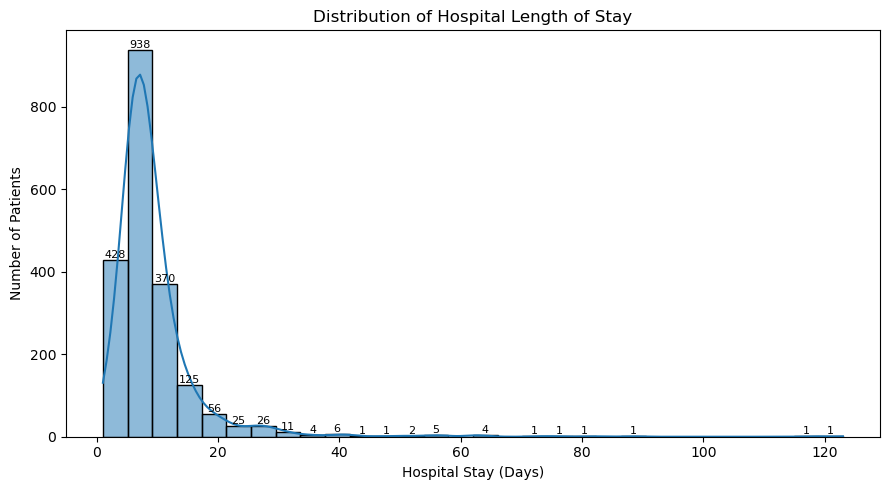

In [76]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    df["dischargeday"].dropna(),
    bins=30,
    kde=True,
    edgecolor="black"
)

# Add labels to histogram bars
for patch in ax.patches:
    height = patch.get_height()
    
    if height > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.title("Distribution of Hospital Length of Stay")
plt.xlabel("Hospital Stay (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

**Define "prolonged hospital stay"**

For this predictive analysis, use the 75th percentile as the definition.

This means patients in approximately the longest 25% of stays are classified as having a prolonged stay.



In [77]:
stay_cutoff = df["dischargeday"].quantile(0.75)

print(
    "Prolonged hospital stay cutoff:",
    stay_cutoff,
    "days"
)

Prolonged hospital stay cutoff: 10.0 days


then:

≤ 10 days → Normal stay

10 days → Prolonged stay

**Create the target**

In [78]:
df["prolonged_stay"] = (
    df["dischargeday"] > stay_cutoff
).astype(int)

**Give the target meaningful labels**

In [79]:
df["prolonged_stay_label"] = df[
    "prolonged_stay"
].map({
    0: "Normal Stay",
    1: "Prolonged Stay"
})

**Check the Distribution**

In [80]:
target_summary = (
    df["prolonged_stay_label"]
    .value_counts()
    .to_frame("Patients")
)

target_summary["Percentage"] = (
    target_summary["Patients"]
    / target_summary["Patients"].sum()
    * 100
)

target_summary

,Patients,Percentage
prolonged_stay_label,,
Normal Stay,1510,75.199
Prolonged Stay,498,24.801


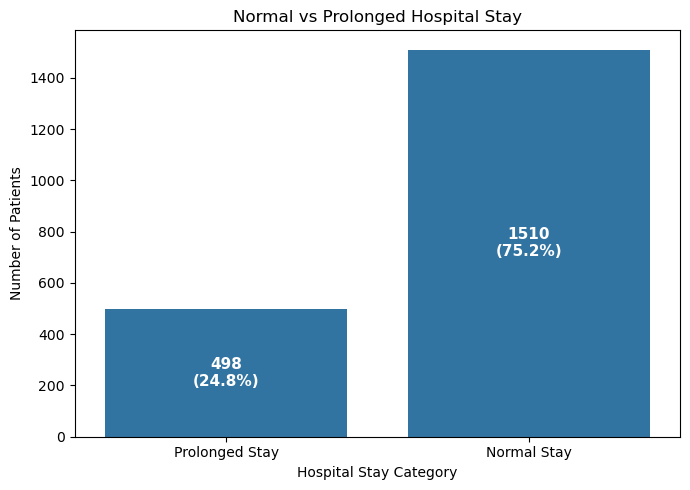

In [81]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="prolonged_stay_label"
)

plt.title("Normal vs Prolonged Hospital Stay")
plt.xlabel("Hospital Stay Category")
plt.ylabel("Number of Patients")

total = len(df)

for container in ax.containers:
    labels = []

    for bar in container:
        count = int(bar.get_height())
        percentage = count / total * 100
        labels.append(f"{count}\n({percentage:.1f}%)")

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**Create log BNP**

**BNP is usually highly skewed, so use a log transformation**

In [82]:
df["brain_natriuretic_peptide"] = pd.to_numeric(
    df["brain_natriuretic_peptide"],
    errors="coerce"
)

df["log_bnp"] = np.log1p(
    df["brain_natriuretic_peptide"]
)

In [83]:
df["log_bnp"].describe()

count   1,973.000
mean        6.538
std         1.235
min         1.306
25%         5.720
50%         6.625
75%         7.461
max         8.517
Name: log_bnp, dtype: float64

**Create comorbidity burden**

From your prescriptive analysis, we previously identified:
- myocardial infarction
- congestive heart failure
- peripheral vascular disease

We can create a simple comorbidity count.

In [84]:
comorbidity_columns = [
    "myocardial_infarction",
    "congestive_heart_failure",
    "peripheral_vascular_disease"
]

df["cardiac_comorbidity_burden"] = (
    df[comorbidity_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

In [85]:
df["cardiac_comorbidity_burden"].value_counts().sort_index()

cardiac_comorbidity_burden
0     126
1    1658
2     214
3      10
Name: count, dtype: int64

**Frozen feature list**

Predictors are listed explicitly and the code raises an error if any is missing, so the model cannot change silently between runs.

- Three originally proposed fields (`age`, `hypertension`, `heart_disease`) do not exist in `patient_master` and are removed by name (age is only available as `age_category`).
- **Echocardiography fields are excluded.** The 7 echo fields are 35–91% missing, so median imputation would invent values for most patients — contradicting our cleaning rule of not fabricating clinical measurements. Echo is also often performed after admission (timing risk). The sensitivity check after the ROC-AUC cell shows they add no predictive value.

In [86]:
# ============================================================
# Q3 — FROZEN FEATURE LIST (replaces the "keep only columns that exist" cell)
# ============================================================
patient_features   = ["gender", "diabetes"]
cardiac_features   = ["nyha_cardiac_function_classification", "killip_grade",
                      "myocardial_infarction", "congestive_heart_failure",
                      "peripheral_vascular_disease"]
lab_features       = ["log_bnp", "glomerular_filtration_rate",
                      "creatinine_enzymatic_method", "urea", "cystatin"]
admission_features = ["admission_ward", "admission_way"]

# Echocardiography fields considered and deliberately excluded (see markdown above)
q3_excluded_echo = ["lvef", "left_ventricular_end_diastolic_diameter_lv",
                    "mitral_valve_ems", "mitral_valve_ams", "ea",
                    "tricuspid_valve_return_velocity", "tricuspid_valve_return_pressure"]

features = patient_features + cardiac_features + lab_features + admission_features

# Fail loudly instead of silently dropping a predictor
q3_not_found = [col for col in features if col not in df.columns]
if q3_not_found:
    raise KeyError(f"Q3 predictors not found in the data: {q3_not_found}")

q3_feature_table = pd.DataFrame({
    "feature": features + q3_excluded_echo,
    "group": (["patient"] * len(patient_features) + ["cardiac"] * len(cardiac_features)
              + ["laboratory"] * len(lab_features) + ["admission"] * len(admission_features)
              + ["echocardiography"] * len(q3_excluded_echo)),
    "included": [True] * len(features) + [False] * len(q3_excluded_echo),
})
q3_feature_table["missing_percent"] = [
    round(df[f].isna().mean() * 100, 1) for f in q3_feature_table["feature"]]
print(f"Features used in model: {len(features)}")
q3_feature_table

Features used in model: 14


,feature,group,included,missing_percent
0,gender,patient,True,0.000
1,diabetes,patient,True,0.000
2,nyha_cardiac_function_classification,cardiac,True,0.000
3,killip_grade,cardiac,True,0.000
4,myocardial_infarction,cardiac,True,0.000
5,congestive_heart_failure,cardiac,True,0.000
6,peripheral_vascular_disease,cardiac,True,0.000
7,log_bnp,laboratory,True,1.700
8,glomerular_filtration_rate,laboratory,True,3.100
9,creatinine_enzymatic_method,laboratory,True,1.100


**Create X and y**

In [87]:
X = df[features].copy()

y = df["prolonged_stay"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2008, 14)
y shape: (2008,)


**Identify numerical and categorical variables**

In [88]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric variables:")
print(numeric_features)

print("\nCategorical variables:")
print(categorical_features)

Numeric variables:
['diabetes', 'nyha_cardiac_function_classification', 'killip_grade', 'myocardial_infarction', 'congestive_heart_failure', 'peripheral_vascular_disease', 'log_bnp', 'glomerular_filtration_rate', 'creatinine_enzymatic_method', 'urea', 'cystatin']

Categorical variables:
['gender', 'admission_ward', 'admission_way']


**Build the preprocessing pipeline**

Numerical variables

Missing values → median Then standardization.

In [89]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

**Categorical variables**

**Missing values → most frequent category Then one-hot encoding.**

In [90]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [91]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

**Create the predictive model**

**We'll use Logistic Regression because this is a binary prediction problem:**

0 = Normal Stay 1 = Prolonged Stay

In [92]:
model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced"
            )
        )
    ]
)

**Use 5-fold cross-validation**
This is important because we don't want to evaluate the model on the exact same observations used to train it.

In [93]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

**Generate out-of-fold predictions:**

In [94]:
y_probability = cross_val_predict(
    model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

**Convert probability to class:**

In [96]:
y_prediction = (
    y_probability >= 0.50
).astype(int)

**Calculate ROC-AUC:Important value for our Predictive Analysis**

In [97]:
q3_cv_auc = roc_auc_score(
    y,
    y_probability
)

print(
    "5-Fold Cross-Validated ROC-AUC:",
    round(q3_cv_auc, 3)
)

5-Fold Cross-Validated ROC-AUC: 0.663


**Is 0.66 better than simple alternatives? Baseline comparison**

An ROC-AUC only has meaning next to a comparison. We score four alternatives with the **same 5 folds, preprocessing and model**:
- **B0** — prevalence only (no patient information);
- **B1** — bedside severity only (NYHA + Killip);
- **B2** — admission route only (ward + admission way);
- **Sensitivity** — the final model plus the 7 excluded echocardiography fields.

In [98]:
# ============================================================
# Q3 — BASELINE COMPARISON (same 5 folds, same preprocessing, same model)
# ============================================================
def q3_cv_model(feature_list, estimator=None):
    # Out-of-fold probabilities for one feature set; preprocessing fitted inside each fold
    num = [c for c in feature_list if pd.api.types.is_numeric_dtype(df[c])]
    cat = [c for c in feature_list if c not in num]
    steps = []
    if num:
        steps.append(("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")),
                                           ("scaler", StandardScaler())]), num))
    if cat:
        steps.append(("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                               ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat))
    estimator = estimator or LogisticRegression(max_iter=3000, class_weight="balanced")
    pipe = Pipeline([("preprocessor", ColumnTransformer(steps)), ("classifier", estimator)])
    return cross_val_predict(pipe, df[feature_list], df["prolonged_stay"],
                             cv=cv, method="predict_proba")[:, 1]

q3_comparison_sets = {
    "B0 Prevalence baseline (no information)": (features, DummyClassifier(strategy="prior")),
    "B1 Severity only (NYHA + Killip)": (["nyha_cardiac_function_classification", "killip_grade"], None),
    "B2 Admission route only (ward + way)": (admission_features, None),
    "Final model (all frozen features)": (features, None),
    "Final model + echo fields (sensitivity)": (features + q3_excluded_echo, None),
}

q3_y = df["prolonged_stay"]
q3_baselines = pd.DataFrame([
    {"model": name,
     "n_features": len(cols),
     "ROC-AUC": roc_auc_score(q3_y, p := q3_cv_model(cols, est)),
     "PR-AUC": average_precision_score(q3_y, p)}
    for name, (cols, est) in q3_comparison_sets.items()
]).set_index("model")
q3_baselines["PR-AUC / prevalence"] = q3_baselines["PR-AUC"] / q3_y.mean()
q3_baselines.round(3)

,n_features,ROC-AUC,PR-AUC,PR-AUC / prevalence
model,,,,
B0 Prevalence baseline (no information),14,0.499,0.248,0.998
B1 Severity only (NYHA + Killip),2,0.545,0.277,1.117
B2 Admission route only (ward + way),2,0.574,0.307,1.238
Final model (all frozen features),14,0.663,0.388,1.564
Final model + echo fields (sensitivity),21,0.664,0.390,1.573


**Hypothesis decision**

The final model's out-of-fold ROC-AUC is **0.663**. It clearly outperforms every simpler alternative scored on the same folds:
- prevalence baseline — 0.50
- bedside severity only (NYHA + Killip) — 0.545
- admission route only (ward + way) — 0.574

Adding the 7 echocardiography fields changes nothing (0.664), which confirms that excluding them costs no predictive value.

**We reject H₀ of no discrimination:** admission-time information does separate prolonged from normal stays, and the combination of labs, comorbidities and admission route adds about +0.09 to +0.12 AUC over either simple baseline.

However, 0.663 falls **below our pre-specified 0.70 threshold** for meaningful discrimination (see the hypothesis cell). We therefore describe the evidence as **modest**: useful for planning at group level, not reliable enough for decisions about individual patients.

**Calculate accuracy, precision, recall and F1**

In [99]:
accuracy = accuracy_score(
    y,
    y_prediction
)

precision = precision_score(
    y,
    y_prediction
)

recall = recall_score(
    y,
    y_prediction
)

f1 = f1_score(
    y,
    y_prediction
)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

Accuracy : 0.645
Precision: 0.364
Recall   : 0.572
F1 Score : 0.445


**Create a model performance table**

In [100]:
performance = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        q3_cv_auc,
        accuracy,
        precision,
        recall,
        f1
    ]
})

performance

,Metric,Value
0,ROC-AUC,0.663
1,Accuracy,0.645
2,Precision,0.364
3,Recall,0.572
4,F1 Score,0.445


**Classification report**

In [101]:
print(
    classification_report(
        y,
        y_prediction,
        target_names=[
            "Normal Stay",
            "Prolonged Stay"
        ]
    )
)

                precision    recall  f1-score   support

   Normal Stay       0.83      0.67      0.74      1510
Prolonged Stay       0.36      0.57      0.44       498

      accuracy                           0.65      2008
     macro avg       0.59      0.62      0.59      2008
  weighted avg       0.71      0.65      0.67      2008



**Confusion matrix**

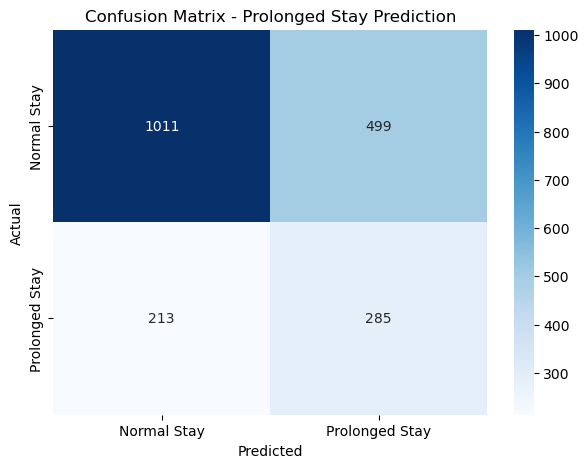

In [102]:
cm = confusion_matrix(
    y,
    y_prediction
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal Stay",
        "Prolonged Stay"
    ],
    yticklabels=[
        "Normal Stay",
        "Prolonged Stay"
    ]
)

plt.title(
    "Confusion Matrix - Prolonged Stay Prediction"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**ROC curve**

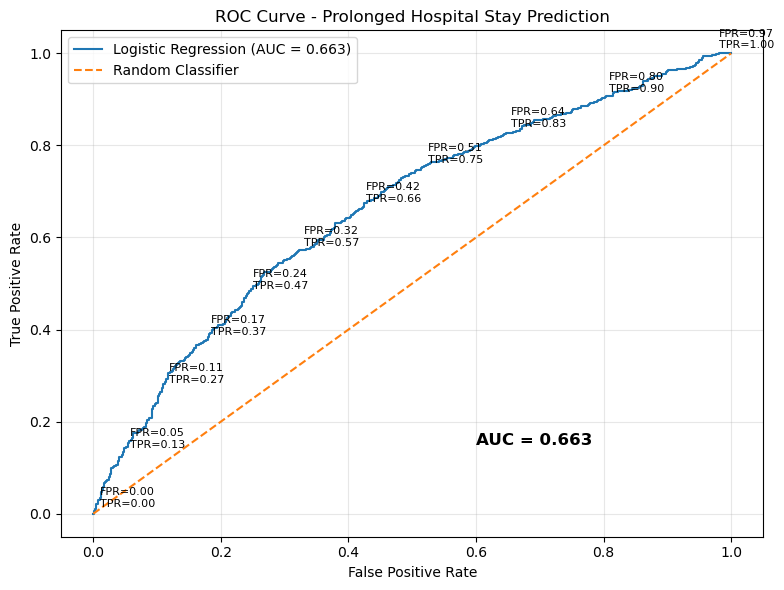

In [103]:
# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y, y_probability)

# Calculate AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC curve
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# Add labels to selected ROC points
step = max(1, len(fpr) // 10)

for i in range(0, len(fpr), step):
    plt.annotate(
        f"FPR={fpr[i]:.2f}\nTPR={tpr[i]:.2f}",
        (fpr[i], tpr[i]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

plt.text(
    0.60,
    0.15,
    f"AUC = {roc_auc:.3f}",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Prolonged Hospital Stay Prediction"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**How to read the ROC curve** — for example, a point labelled FPR = 0.20, TPR = 0.75 means:

**FPR = 0.20 → 20% of patients who actually had a normal stay were incorrectly predicted as prolonged stay.**

**TPR = 0.75 → 75% of patients who actually had a prolonged stay were correctly identified by the model.**

**The AUC value in the legend summarizes the model's ability to distinguish between normal and prolonged hospital stays**

**Fit the final model**

In [104]:
model.fit(X, y)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
**Identify important predictors**

In [105]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [106]:
coefficients = (
    model
    .named_steps["classifier"]
    .coef_[0]
)

In [107]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance[
    "Absolute_Importance"
] = feature_importance[
    "Coefficient"
].abs()

feature_importance = (
    feature_importance
    .sort_values(
        "Absolute_Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Coefficient,Absolute_Importance
13,categorical__admission_ward_Cardiology,-0.589,0.589
15,categorical__admission_ward_ICU,0.521,0.521
10,numeric__cystatin,0.475,0.475
16,categorical__admission_ward_Others,0.416,0.416
18,categorical__admission_way_Non Emergency,0.235,0.235
8,numeric__creatinine_enzymatic_method,-0.229,0.229
0,numeric__diabetes,0.200,0.200
14,categorical__admission_ward_General Ward,-0.188,0.188
12,categorical__gender_Male,0.120,0.120
9,numeric__urea,0.114,0.114


**Plot the top predictors**

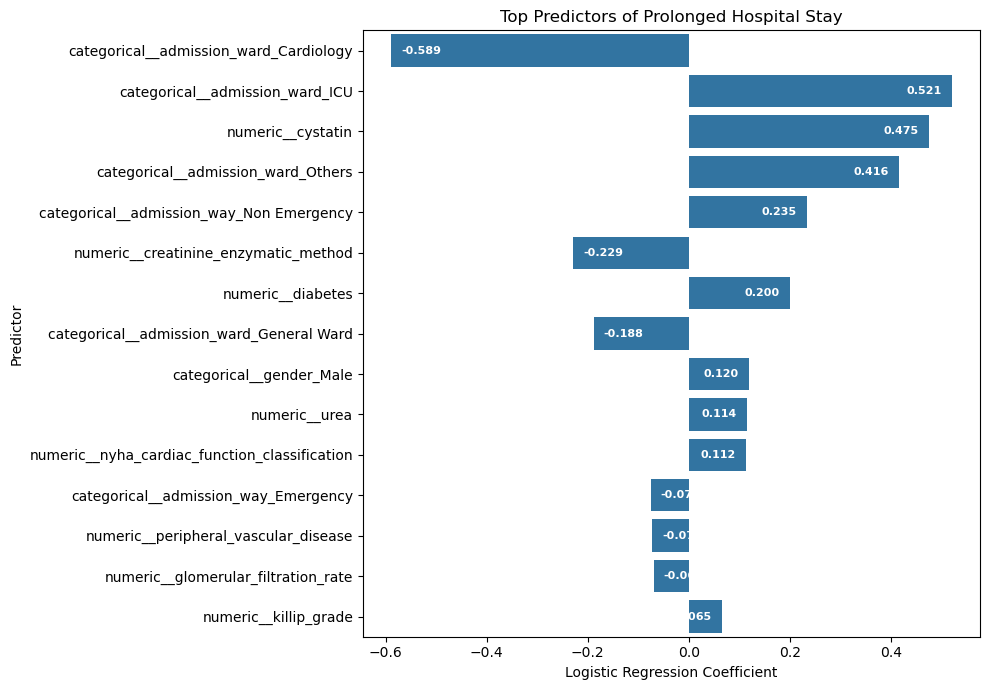

In [108]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Predictors of Prolonged Hospital Stay")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Predictor")

# Add coefficient values inside the bars
for container in ax.containers:
    for bar in container:
        value = bar.get_width()

        if value >= 0:
            x_position = value - 0.02
            ha = "right"
        else:
            x_position = value + 0.02
            ha = "left"

        ax.text(
            x_position,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}",
            ha=ha,
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

**Interpretation:** Positive coefficient → higher predicted probability of prolonged stay.

Negative coefficient → lower predicted probability.

Larger absolute coefficient → stronger contribution within this model.

This should be described as association/prediction, not causation.

**Caution — correlated renal markers:** GFR, creatinine, urea and cystatin all measure kidney function and are strongly correlated. Their individual coefficients can take opposite signs (e.g. creatinine negative, cystatin positive) because they share information, so they should be interpreted as a group, not one by one.

**Create patient-level predicted risk**

In [109]:
prediction_results = df[
    [
        "inpatient_number",
        "dischargeday",
        "prolonged_stay"
    ]
].copy()

prediction_results[
    "Predicted_Probability"
] = y_probability

prediction_results[
    "Predicted_Risk_Group"
] = np.where(
    prediction_results[
        "Predicted_Probability"
    ] >= 0.50,
    "Higher Risk",
    "Lower Risk"
)

prediction_results.head()

,inpatient_number,dischargeday,prolonged_stay,Predicted_Probability,Predicted_Risk_Group
0,857781,11,1,0.614,Higher Risk
1,743087,8,0,0.416,Lower Risk
2,866418,5,0,0.503,Higher Risk
3,775928,11,1,0.450,Lower Risk
4,810128,5,0,0.396,Lower Risk


**Compare predicted risk groups**

In [110]:
risk_summary = (
    prediction_results
    .groupby("Predicted_Risk_Group")
    .agg(
        Patients=(
            "inpatient_number",
            "count"
        ),
        Actual_Prolonged_Stays=(
            "prolonged_stay",
            "sum"
        ),
        Average_Stay=(
            "dischargeday",
            "mean"
        )
    )
)

risk_summary[
    "Prolonged_Stay_Rate_%"
] = (
    risk_summary["Actual_Prolonged_Stays"]
    / risk_summary["Patients"]
    * 100
)

risk_summary

,Patients,Actual_Prolonged_Stays,Average_Stay,Prolonged_Stay_Rate_%
Predicted_Risk_Group,,,,
Higher Risk,784,285,11.158,36.352
Lower Risk,1224,213,8.308,17.402


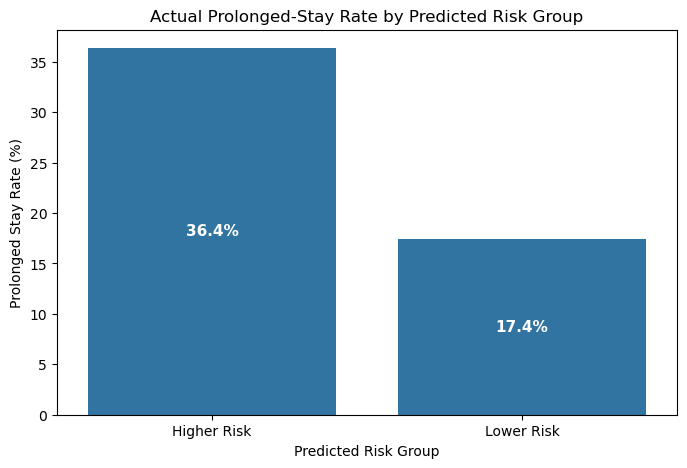

In [111]:
plot_data = (
    risk_summary
    .reset_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_data,
    x="Predicted_Risk_Group",
    y="Prolonged_Stay_Rate_%"
)

plt.title(
    "Actual Prolonged-Stay Rate by Predicted Risk Group"
)

plt.xlabel("Predicted Risk Group")
plt.ylabel("Prolonged Stay Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
         label_type="center",
        color="white",
         fontsize=11,
        fontweight="bold",
        fmt="%.1f%%"
    )

plt.show()

**Very important: leakage check**

Your model must not use information that becomes available after the hospitalization.

Do not use these as predictors:

In [112]:
leakage_variables = [
    "dischargeday",
    "destination_discharge",
    "discharge_department",
    "outcome_during_hospitalization",
    "death_within_28_days",
    "re_admission_within_28_days",
    "death_within_3_months",
    "re_admission_within_3_months",
    "death_within_6_months",
    "re_admission_within_6_months",
    "time_of_death_days_from_admission",
    "readmission_time_days_from_admission",
    "return_to_emergency_department_within_6_months",
    "time_to_emergency_department_within_6_months"
]

In [113]:
[x for x in features if x in leakage_variables]

[]

dischargeday is used only to create the target and is not included in X

**Final predictive-analysis summary**

In [114]:
final_summary = pd.DataFrame({
    "Measure": [
        "Total Patients",
        "Prolonged-Stay Cutoff (days)",
        "Prolonged-Stay Patients",
        "Prolonged-Stay Percentage",
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Result": [
        len(df),
        round(stay_cutoff, 2),
        int(y.sum()),
        round(y.mean() * 100, 2),
        round(roc_auc, 3),
        round(accuracy, 3),
        round(precision, 3),
        round(recall, 3),
        round(f1, 3)
    ]
})

final_summary

,Measure,Result
0,Total Patients,"2,008.000"
1,Prolonged-Stay Cutoff (days),10.000
2,Prolonged-Stay Patients,498.000
3,Prolonged-Stay Percentage,24.800
4,ROC-AUC,0.663
5,Accuracy,0.645
6,Precision,0.364
7,Recall,0.572
8,F1 Score,0.445


**Predictive-Analysis Framework**

**Initial admission information** → patient characteristics, cardiac severity (NYHA, Killip), comorbidities, BNP, renal markers, admission ward and route → **logistic regression** (5-fold cross-validated) → predicted probability of prolonged stay → lower-risk vs higher-risk groups.

**Conclusion:** Using only information available at admission, the model ranks patients by their risk of a prolonged stay (> 10 days) with modest discrimination (cross-validated ROC-AUC 0.663). This is clearly better than bedside severity alone (0.545) or admission route alone (0.574), but below our pre-specified 0.70 threshold for meaningful individual prediction.

The value is at **group level**. Patients in the predicted higher-risk group had a prolonged-stay rate of about 36% versus 17% in the lower-risk group (roughly 2×), and an average stay of about 11.2 versus 8.3 days. That is enough to support bed-capacity forecasting and earlier discharge planning, not to make decisions for individual patients.

**Limitations:**
- Performance is estimated with 5-fold cross-validation, with no separate held-out test set.
- The 0.50 classification threshold is the default, not chosen for a specific bed-capacity target.
- Lab timing is assumed to be admission-time (there are no timestamps).
- Patients who died in hospital (11) are included, and their stays may be cut short by death rather than recovery.

The identified predictors are associations and should not be interpreted as causes of prolonged hospital stay.

## Q4. Predicting Six-Month Mortality

#### Question
Can we predict which patients are at higher risk of death within six months using information available at initial admission?

#### Why?

Six-month mortality is an important patient outcome. Predicting mortality risk using information available at initial admission can help identify patients who may require closer monitoring and follow-up.

For this analysis, the timing of the information is critical. We want the model to use information that would have been available at initial admission and avoid information that may only become available later in the patient's hospitalization.

#### What?

We will use the existing patient-level `patient_master` dataset and define:

- **Target:** `death_within_6_months`
- **Unit of analysis:** One row per patient
- **Prediction point:** Initial admission
- **Prediction horizon:** Six months after admission

Before selecting predictors or building a model, we will first validate the mortality outcome and understand its distribution.

#### How?

We create a separate Q4 working copy of `patient_master`.

The original `patient_master` dataset will remain unchanged so that the existing Q1, Q2, and Q3 analyses are not affected.

#### What do we expect to achieve?

At the end of this step, we expect to have:

1. A separate Q4 working dataset.
2. Confirmation that the dataset remains at the patient level.
3. Confirmation that the six-month mortality target exists.
4. A clear definition of the outcome that will be predicted.

The next step will examine the distribution and completeness of the six-month mortality outcome before we select predictors.


In [116]:
# ============================================================
# Q4 — CONFIGURATION
# ============================================================
Q4_RANDOM_STATE   = RANDOM_STATE   # 42, defined in the notebook's import cell
Q4_N_SPLITS       = 5              # folds per repeat
Q4_N_REPEATS      = 10             # repeats of the 5-fold split
Q4_N_BOOTSTRAP    = 2000           # bootstrap resamples for confidence intervals
Q4_N_PERMUTATIONS = 200            # label shuffles for the permutation test
Q4_FLAG_SHARE     = 0.20           # share of patients a follow-up team could prioritise
Q4_ALPHA          = 0.05

### Hypothesis

#### Null Hypothesis — H₀

Admission-time patient characteristics do not provide useful discrimination between patients who die within six months and patients who survive.

#### Alternative Hypothesis — H₁

Admission-time patient characteristics provide useful discrimination between patients who die within six months and patients who survive.

### How we will evaluate the hypothesis (decision rule fixed before modelling)

We separate **statistical signal** from **practical usefulness**, and fix the rules before looking at any model result:

1. **Statistical signal (tests H₀):** a label-permutation test on the cross-validated ROC-AUC. H₀ is rejected only if p < 0.05 **and** the 95% bootstrap confidence interval of the ROC-AUC lies entirely above 0.50.
2. **Added value over clinical judgement:** the admission model must beat a severity-only baseline (NYHA + Killip); the 95% CI of the AUC difference must exclude 0.
3. **Practical usefulness (judged separately):** PR-AUC relative to prevalence, deaths captured when a fixed share of patients is flagged, Brier score versus the prevalence baseline, and calibration.

Because six-month death is rare (57 events), performance is estimated with **repeated stratified cross-validation**: every patient is scored by a model that never saw them during training (Step 7 explains why this replaces a single train/test split).

### Prediction Point

#### When are we making the prediction?
The prediction is made at **initial hospital admission**.

Therefore, predictors should represent information that would reasonably be available at or very near the initial admission decision point.

#### Why this matters
A predictive model must only use information that would actually be available when the prediction is supposed to be made.

Using information recorded after admission — such as complications, discharge outcomes, length of stay, later procedures, or later laboratory measurements — could introduce **data leakage**.

Data leakage can make a model appear more predictive than it would be in a real-world setting.

Therefore, before modeling, every candidate predictor will be reviewed for:

1. clinical meaning;
2. availability at initial admission;
3. relationship to the six-month outcome;
4. possibility of being recorded after the prediction point.

### Step 1 — Define the Prediction Problem

**Why?** Q1–Q3 use the same `patient_master`. Earlier versions of this notebook overwrote the shared dataframe, which broke every later cell. Q4 therefore works on its own copy, and `patient_master` is never modified.

**What?** A Q4 working copy, confirmation that the target exists, and confirmation that the data is still one row per patient.

**What we expect:** 2,008 rows, 2,008 unique patients, 0 duplicate IDs.

In [117]:
# ============================================================
# Q4 — STEP 1: DEFINE THE PREDICTION PROBLEM
# ============================================================
q4_df = patient_master.copy()          # patient_master itself is never modified
q4_target = "death_within_6_months"

if q4_target not in q4_df.columns:
    raise KeyError(f"Q4 target '{q4_target}' was not found in patient_master.")

q4_structure = pd.Series({
    "rows": len(q4_df),
    "unique_patients": q4_df["inpatient_number"].nunique(),
    "duplicate_patient_ids": q4_df["inpatient_number"].duplicated().sum(),
})
assert q4_structure["duplicate_patient_ids"] == 0, "Q4 expects one row per patient."
q4_structure

rows                     2008
unique_patients          2008
duplicate_patient_ids       0
dtype: int64

### Step 2 — Validate the Six-Month Mortality Outcome

**Why?** A classifier needs a clean binary target. We also need the event rate: a rare outcome changes how the model must be validated and which metrics are meaningful (accuracy becomes misleading, because predicting "survives" for everyone would already be ~97% accurate).

**What?** Allowed values (0/1 only), counts, percentages and missing values of `death_within_6_months`. The target is not modified or imputed.

**What we expect:** a complete, strictly binary target with a low event rate.

In [118]:
# ============================================================
# Q4 — STEP 2: VALIDATE THE SIX-MONTH MORTALITY OUTCOME
# ============================================================
q4_unexpected_values = set(q4_df[q4_target].dropna().unique()) - {0, 1}
assert not q4_unexpected_values, f"Unexpected target values: {q4_unexpected_values}"

q4_outcome_summary = (
    q4_df[q4_target]
    .value_counts(dropna=False)
    .rename_axis(q4_target)
    .reset_index(name="patients")
)
q4_outcome_summary["percentage"] = (q4_outcome_summary["patients"] / len(q4_df) * 100).round(2)

q4_deaths     = int((q4_df[q4_target] == 1).sum())
q4_non_deaths = int((q4_df[q4_target] == 0).sum())
q4_missing    = int(q4_df[q4_target].isna().sum())

print(f"Deaths within 6 months  : {q4_deaths:,}")
print(f"No death within 6 months: {q4_non_deaths:,}")
print(f"Missing outcome         : {q4_missing:,}")
q4_outcome_summary

Deaths within 6 months  : 57
No death within 6 months: 1,951
Missing outcome         : 0


,death_within_6_months,patients,percentage
0,0,1951,97.160
1,1,57,2.840


**What we found:** the target is complete and strictly binary — 57 deaths and 1,951 survivors (2.84%). With only 57 events, every modelling choice from here on must protect against overfitting and unstable estimates.

### Step 3 — Define the Eligible Prediction Cohort

**Why?** A model can only learn from patients whose outcome is known. Since Step 2 found no missing outcomes, no patient is excluded, and both outcome groups are retained. The class imbalance is a property of the population we want to predict for, so it is not "fixed" by removing survivors.

**What we expect:** 2,008 eligible patients, 57 deaths, 0 exclusions.

In [119]:
# ============================================================
# Q4 — STEP 3: DEFINE THE ELIGIBLE PREDICTION COHORT
# ============================================================
q4_model_df = q4_df[q4_df[q4_target].notna()].copy()
q4_model_df[q4_target] = q4_model_df[q4_target].astype(int)

q4_mortality_prevalence = q4_model_df[q4_target].mean()

print(f"Eligible Q4 patients           : {len(q4_model_df):,}")
print(f"Excluded due to missing outcome: {len(q4_df) - len(q4_model_df):,}")
print(f"Six-month mortality prevalence : {q4_mortality_prevalence:.2%}")

Eligible Q4 patients           : 2,008
Excluded due to missing outcome: 0
Six-month mortality prevalence : 2.84%


### Step 3B — When Do the Deaths Happen? (Outcome Timing and Leakage Check)

**Why?** "Six-month mortality" can mean very different things clinically. If most deaths happen within days of admission, a model is really predicting **acute, in-hospital deterioration**; if most happen after discharge, it is predicting **post-discharge risk**. This changes who would use the model and when. The same check also exposes hospital-stay variables that are strongly tied to death but only known *after* admission — these must be excluded as predictors.

**What?** The overlap of six-month death with 28-day death, the in-hospital outcome, the recorded day of death, and the event-time quality flags created during cleaning.

**Counter-argument:** one could argue that `outcome_during_hospitalization` (e.g. "Discharge Against Order") is a useful predictor because it is strongly associated with death. It is excluded because it is only known at discharge; including it would answer a different question ("who dies after we already know how the stay ended?").

**What we expect:** a large share of deaths to occur early, since this is an acutely hospitalised heart-failure cohort.

In [120]:
# ============================================================
# Q4 — STEP 3B: OUTCOME TIMING AND LEAKAGE CHECK
# ============================================================
q4_dead = q4_model_df[q4_model_df[q4_target] == 1]

q4_timing_summary = pd.Series({
    "deaths within 6 months": len(q4_dead),
    "  of which within 28 days": int(q4_dead["death_within_28_days"].eq(1).sum()),
    "  of which died during the index stay": int(q4_dead["outcome_during_hospitalization"].eq("Dead").sum()),
    "  of which day of death recorded": int(q4_dead["time_of_death_days_from_admission"].notna().sum()),
    "  median day of death (recorded)": q4_dead["time_of_death_days_from_admission"].median(),
    "  deaths with missing event time (flag)": int(q4_dead["event_time_missing_flag"].sum()),
    "  deaths with contradictory event times (flag)": int(q4_dead["event_time_contradiction_flag"].sum()),
})
display(q4_timing_summary.to_frame("value"))

# Mortality by how the index stay ended — shown to justify EXCLUDING this variable
q4_by_stay_outcome = (
    q4_model_df.groupby("outcome_during_hospitalization")[q4_target]
    .agg(patients="size", deaths="sum", mortality_rate="mean")
    .assign(mortality_rate=lambda t: (t["mortality_rate"] * 100).round(1))
)
q4_by_stay_outcome

,value
deaths within 6 months,57.000
of which within 28 days,37.000
of which died during the index stay,11.000
of which day of death recorded,41.000
median day of death (recorded),4.000
deaths with missing event time (flag),16.000
deaths with contradictory event times (flag),1.000


,patients,deaths,mortality_rate
outcome_during_hospitalization,,,
Alive,1890,26,1.400
Dead,11,11,100.000
Discharge Against Order,107,20,18.700


**What we found:**
- 37 of the 57 deaths (65%) occurred within 28 days, 11 during the index stay, and the median recorded day of death is day 4. Q4 is therefore **largely an early-mortality question**; Step 13 checks whether the model still works once in-hospital deaths are removed.
- 20 of the 107 patients who were discharged against medical advice died within six months (18.7%, versus 1.4% among those discharged alive normally). This is a strong association, but it is a **discharge-time** fact, so it is excluded from the predictors.
- 16 deaths have no recorded event time, and 1 death carries the event-time contradiction flag. The death flag itself is present for all of them, so they are kept in the cohort; the missing times only limit the timing description above.

**Why it matters:** the model is positioned as an **admission-day risk-stratification tool**, and all discharge-time variables are explicitly off-limits.

### Step 4 — Candidate Predictors Available at Initial Admission

**Why?** Predictors must (a) have a clinical reason to be linked to death, (b) be available at admission, and (c) exist in the actual dataset. We name candidates from clinical reasoning and the Category 3 findings first, *then* check the data — we do not scan all 198 columns for whatever correlates best with death, which would overfit 57 events.

**What?** Seven candidates covering different dimensions of risk:

| Predictor | Column | Clinical reason |
|---|---|---|
| Kidney function | `glomerular_filtration_rate` | Cardiorenal syndrome — reduced kidney function is one of the strongest mortality markers in heart failure |
| Comorbidity burden | `cci_score` | More chronic disease means less physiological reserve |
| Functional status | `nyha_cardiac_function_classification` | Symptom severity in daily activity |
| Acute cardiac severity | `killip_grade` | Signs of congestion / cardiogenic shock at presentation |
| Cardiac wall stress | `brain_natriuretic_peptide` | Released when the ventricles are stretched; tracks decompensation |
| Diabetes | `diabetes` | Common cardiometabolic comorbidity |
| Chronic kidney disease | `moderate_to_severe_chronic_kidney_disease` | Diagnosed kidney disease |

In [121]:
# ============================================================
# Q4 — STEP 4: AUDIT CANDIDATE ADMISSION-TIME PREDICTORS
# ============================================================
q4_candidate_features = [
    "glomerular_filtration_rate",
    "cci_score",
    "nyha_cardiac_function_classification",
    "killip_grade",
    "brain_natriuretic_peptide",
    "diabetes",
    "moderate_to_severe_chronic_kidney_disease",
]

q4_missing_columns = [f for f in q4_candidate_features if f not in q4_model_df.columns]
if q4_missing_columns:
    # Fail loudly instead of silently dropping predictors (a Q3 review finding)
    raise KeyError(f"Candidate predictors not found in patient_master: {q4_missing_columns}")

q4_feature_audit = pd.DataFrame({
    "feature": q4_candidate_features,
    "dtype": [str(q4_model_df[f].dtype) for f in q4_candidate_features],
    "missing_count": [int(q4_model_df[f].isna().sum()) for f in q4_candidate_features],
})
q4_feature_audit["missing_percent"] = (q4_feature_audit["missing_count"] / len(q4_model_df) * 100).round(2)
q4_feature_audit

,feature,dtype,missing_count,missing_percent
0,glomerular_filtration_rate,float64,63,3.140
1,cci_score,float64,5,0.250
2,nyha_cardiac_function_classification,int64,0,0.000
3,killip_grade,int64,0,0.000
4,brain_natriuretic_peptide,float64,35,1.740
5,diabetes,int64,0,0.000
6,moderate_to_severe_chronic_kidney_disease,float64,2,0.100


### Step 4B — Inspect Values and Their Relationship With the Outcome

**Why?** Before modelling we check that scores contain plausible categories, numeric values are usable, and we note data-quality issues that affect interpretation (e.g. assay ceilings).

We also check **how `cci_score` is constructed**, because diabetes and CKD are both Charlson comorbidities. If they are already inside the score, adding them again would double-count the same information.

In [122]:
# ============================================================
# Q4 — STEP 4B: INSPECT CANDIDATE PREDICTOR VALUES
# ============================================================
q4_categorical_candidates = [
    "nyha_cardiac_function_classification", "killip_grade",
    "diabetes", "moderate_to_severe_chronic_kidney_disease",
]
q4_numeric_candidates = ["glomerular_filtration_rate", "cci_score", "brain_natriuretic_peptide"]

# Event rate within every category — plausibility check and first look at signal
for feature in q4_categorical_candidates:
    q4_tab = (
        q4_model_df.groupby(feature, dropna=False)[q4_target]
        .agg(patients="size", deaths="sum", mortality_pct="mean")
        .assign(mortality_pct=lambda t: (t["mortality_pct"] * 100).round(1))
    )
    print(f"\n{feature}\n{q4_tab}")

display(q4_model_df[q4_numeric_candidates].describe().T.round(2))

# BNP assay ceiling: how many values sit exactly at the maximum?
q4_bnp_max = q4_model_df["brain_natriuretic_peptide"].max()
q4_bnp_at_ceiling = int((q4_model_df["brain_natriuretic_peptide"] == q4_bnp_max).sum())
print(f"BNP maximum = {q4_bnp_max:,.0f} pg/mL; patients at that exact value: {q4_bnp_at_ceiling}")

# Is cci_score simply the count of the 16 Charlson comorbidity flags?
q4_cci_components = [
    "myocardial_infarction", "congestive_heart_failure", "peripheral_vascular_disease",
    "cerebrovascular_disease", "dementia", "chronic_obstructive_pulmonary_disease",
    "connective_tissue_disease", "peptic_ulcer_disease", "diabetes",
    "moderate_to_severe_chronic_kidney_disease", "hemiplegia", "leukemia",
    "malignant_lymphoma", "solid_tumor", "liver_disease", "aids",
]
q4_flag_count = q4_model_df[q4_cci_components].sum(axis=1, min_count=len(q4_cci_components))
q4_comparable = q4_model_df["cci_score"].notna() & q4_flag_count.notna()
q4_cci_matches = int((q4_model_df.loc[q4_comparable, "cci_score"] == q4_flag_count[q4_comparable]).sum())
print(f"cci_score equals the count of the 16 comorbidity flags in "
      f"{q4_cci_matches:,} of {int(q4_comparable.sum()):,} comparable patients")

# GFR distribution by diagnosed-CKD flag (overlap check)
q4_model_df.groupby("moderate_to_severe_chronic_kidney_disease")["glomerular_filtration_rate"].describe().round(1)


nyha_cardiac_function_classification
                                      patients  deaths  mortality_pct
nyha_cardiac_function_classification                                 
2                                          353       9          2.500
3                                         1039      18          1.700
4                                          616      30          4.900

killip_grade
              patients  deaths  mortality_pct
killip_grade                                 
1                  527       4          0.800
2                 1029      16          1.600
3                  392      21          5.400
4                   60      16         26.700

diabetes
          patients  deaths  mortality_pct
diabetes                                 
0             1542      44          2.900
1              466      13          2.800

moderate_to_severe_chronic_kidney_disease
                                           patients  deaths  mortality_pct
moderate_to_severe_chronic

,count,mean,std,min,25%,50%,75%,max
glomerular_filtration_rate,"1,945.000",68.660,36.610,3.130,41.600,64.790,90.120,281.010
cci_score,"2,003.000",1.860,0.960,0.000,1.000,2.000,2.000,6.000
brain_natriuretic_peptide,"1,973.000","1,280.440","1,354.160",2.690,303.940,753.030,"1,738.520","5,000.000"


BNP maximum = 5,000 pg/mL; patients at that exact value: 100
cci_score equals the count of the 16 comorbidity flags in 2,003 of 2,003 comparable patients


,count,mean,std,min,25%,50%,75%,max
moderate_to_severe_chronic_kidney_disease,,,,,,,,
0.000,"1,482.000",77.600,34.900,3.100,53.700,73.900,96.300,281.000
1.000,461.000,40.000,25.600,3.600,24.800,36.600,49.100,257.700


**What we found:**
- All categories are plausible. NYHA contains only classes 2–4 (a hospitalised cohort), Killip 1–4.
- Killip grade shows a steep, ordered gradient in mortality (about 0.8% → 1.6% → 5.4% → 26.7% across grades 1–4). NYHA is **not** monotonic: class 3 (1.7%) is slightly lower than class 2 (2.5%), and risk is elevated only at class 4 (4.9%).
- Diabetes shows **no** difference in six-month mortality (2.9% vs 2.8%).
- 100 patients sit exactly at BNP = 5,000 pg/mL. This is an assay/reporting ceiling, so BNP is **censored** at the top: the model cannot distinguish 5,000 from much higher true values. We keep BNP (log-transformed) and state this as a limitation.
- **`cci_score` is exactly the unweighted count of the 16 comorbidity flags** in all 2,003 comparable patients — so it already contains `diabetes` and `moderate_to_severe_chronic_kidney_disease`.
- Patients flagged with CKD have much lower median GFR, but the ranges overlap heavily, confirming that the flag and the lab measure describe the same organ system.

### Step 4C — Predictor Timing, Redundancy and Final Decision

**Why?** Being present in the dataset is not enough. Each candidate is judged on timing, redundancy and statistical cost, and the decision is recorded in a table so a reviewer can see exactly which predictors survived and why.

**Events-per-variable (EPV):** with 57 deaths, a common rule of thumb for logistic regression is at least ~10 events per estimated coefficient. That allows roughly **5 predictors**. Every redundant predictor spends part of that budget and increases overfitting.

**Timing assumption (stated, not assumed silently):** the dataset stores one value per patient for labs and scores, without timestamps. We treat NYHA, Killip, BNP and GFR as admission-time assessments because they are the standard admission work-up for heart failure. This cannot be verified from the data itself and is listed as a limitation.

**Counter-argument:** dropping diabetes and CKD loses information. It does not — both are already counted inside `cci_score`, and kidney function is represented more precisely by the measured GFR. Keeping them would also mean the same comorbidity is counted twice. We base this on **how the variables are constructed**, not on which variable happened to predict death best.

In [123]:
# ============================================================
# Q4 — STEP 4C: PREDICTOR TIMING & REDUNDANCY DECISION TABLE
# ============================================================
q4_predictor_review = pd.DataFrame([
    ["glomerular_filtration_rate", "Kidney function (measured)",
     "Admission lab (assumed; no timestamp)", "Include",
     "Continuous measured kidney function; more informative than the diagnosis flag"],
    ["cci_score", "Comorbidity burden",
     "Pre-existing history", "Include",
     "Summarises all 16 comorbidities in one coefficient"],
    ["nyha_cardiac_function_classification", "Functional status",
     "Admission assessment", "Include",
     "Standard heart-failure severity scale"],
    ["killip_grade", "Acute cardiac severity",
     "Admission assessment", "Include",
     "Congestion / shock signs at presentation"],
    ["brain_natriuretic_peptide", "Cardiac wall stress",
     "Admission lab (assumed; no timestamp)", "Include (log-transformed)",
     "Strongly right-skewed with a 5,000 pg/mL ceiling; log scale reduces the pull of extreme values"],
    ["diabetes", "Comorbidity",
     "Pre-existing history", "Exclude",
     "Already counted inside cci_score (verified in Step 4B)"],
    ["moderate_to_severe_chronic_kidney_disease", "Kidney disease diagnosis",
     "Pre-existing history", "Exclude",
     "Already counted inside cci_score and represented by measured GFR"],
], columns=["feature", "clinical_role", "timing", "decision", "reason"])

q4_predictor_review = q4_predictor_review.merge(
    q4_feature_audit[["feature", "missing_percent"]], on="feature", how="left"
)

# Variables explicitly excluded as post-admission (leakage) — documented, never used
q4_leakage_blacklist = [
    "outcome_during_hospitalization", "destination_discharge", "dischargeday",
    "discharge_department", "death_within_28_days", "death_within_3_months",
    "time_of_death_days_from_admission", "re_admission_within_28_days",
    "re_admission_within_3_months", "re_admission_within_6_months",
    "readmission_time_days_from_admission",
    "return_to_emergency_department_within_6_months",
    "total_drug_count",   # plus all drug_* flags: prescribed during the stay
]
print(f"Post-admission variables excluded as leakage: {len(q4_leakage_blacklist)} "
      f"(+ all drug_* prescription flags)")
q4_predictor_review

Post-admission variables excluded as leakage: 13 (+ all drug_* prescription flags)


,feature,clinical_role,timing,decision,reason,missing_percent
0,glomerular_filtration_rate,Kidney function (measured),Admission lab (assumed; no timestamp),Include,Continuous measured kidney function; more info...,3.140
1,cci_score,Comorbidity burden,Pre-existing history,Include,Summarises all 16 comorbidities in one coeffic...,0.250
2,nyha_cardiac_function_classification,Functional status,Admission assessment,Include,Standard heart-failure severity scale,0.000
3,killip_grade,Acute cardiac severity,Admission assessment,Include,Congestion / shock signs at presentation,0.000
4,brain_natriuretic_peptide,Cardiac wall stress,Admission lab (assumed; no timestamp),Include (log-transformed),"Strongly right-skewed with a 5,000 pg/mL ceili...",1.740
5,diabetes,Comorbidity,Pre-existing history,Exclude,Already counted inside cci_score (verified in ...,0.000
6,moderate_to_severe_chronic_kidney_disease,Kidney disease diagnosis,Pre-existing history,Exclude,Already counted inside cci_score and represent...,0.100


### Step 5 — Freeze the Feature Sets for Each Model

**Why?** The Q2 review flagged that changing features after seeing test results indirectly leaks the test set. Here the feature sets are fixed **before** any model is trained and are never changed afterwards.

**What?** Three nested models, so each one answers a specific question:

| Model | Predictors | Question it answers |
|---|---|---|
| **M0 — Prevalence baseline** | none (predicts 2.84% for everyone) | What does "no information" look like? |
| **M1 — Severity baseline** | NYHA + Killip | How far does routine bedside clinical severity get us? |
| **M2 — Admission model** | NYHA + Killip + log BNP + GFR + CCI | Do labs and comorbidity burden add value beyond bedside severity? |

M2 uses 5 predictors → about 11 events per predictor, within the EPV budget.

**How (preprocessing, all learned inside each training fold only):** median imputation for the few missing values (GFR 3.1%, BNP 1.7%, CCI 0.2%), log(1 + x) for BNP, and standardisation so coefficients are comparable per 1 SD. NYHA and Killip are kept as single ordinal numbers. For Killip this matches the data (mortality rises at every grade). For NYHA it is a simplification — risk is elevated mainly at class 4 (Step 4B) — but one-hot encoding both scores would cost 3 extra coefficients the 57 events cannot support. GFR is also entered as a straight-line term, although Step 6 shows its risk is concentrated below 30; both simplifications are listed as limitations rather than tuned on this data.

In [124]:
# ============================================================
# Q4 — STEP 5: FREEZE FEATURE SETS AND BUILD PIPELINES
# ============================================================
Q4_SEVERITY_FEATURES  = ("nyha_cardiac_function_classification", "killip_grade")
Q4_ADMISSION_FEATURES = Q4_SEVERITY_FEATURES + (
    "brain_natriuretic_peptide", "glomerular_filtration_rate", "cci_score",
)
Q4_LOG_FEATURES = ("brain_natriuretic_peptide",)

# Guard: the frozen sets must match the decisions recorded in Step 4C
q4_included = set(q4_predictor_review.loc[
    q4_predictor_review["decision"].str.startswith("Include"), "feature"])
assert set(Q4_ADMISSION_FEATURES) == q4_included, "Frozen features differ from the Step 4C decision table."


def q4_build_logistic_pipeline(features):
    # Imputation, log transform and scaling are fitted inside each training fold only.
    plain = [f for f in features if f not in Q4_LOG_FEATURES]
    logged = [f for f in features if f in Q4_LOG_FEATURES]
    transformers = []
    if plain:
        transformers.append(("plain", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), plain))
    if logged:
        transformers.append(("logged", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", StandardScaler()),
        ]), logged))
    # No class_weight: we want probabilities that reflect true risk (see Step 11)
    return Pipeline([
        ("prep", ColumnTransformer(transformers)),
        ("model", LogisticRegression(max_iter=1000)),
    ])


q4_models = {
    "M0 Prevalence baseline": (Pipeline([("model", DummyClassifier(strategy="prior"))]),
                               list(Q4_ADMISSION_FEATURES)),
    "M1 Severity (NYHA+Killip)": (q4_build_logistic_pipeline(Q4_SEVERITY_FEATURES),
                                  list(Q4_SEVERITY_FEATURES)),
    "M2 Admission model": (q4_build_logistic_pipeline(Q4_ADMISSION_FEATURES),
                           list(Q4_ADMISSION_FEATURES)),
}

q4_X = q4_model_df[list(Q4_ADMISSION_FEATURES)].copy()
q4_y = q4_model_df[q4_target].to_numpy()
print(f"Q4 modelling matrix: {q4_X.shape[0]:,} patients x {q4_X.shape[1]} predictors; "
      f"{q4_y.sum()} deaths ({q4_y.sum() / q4_X.shape[1]:.1f} events per predictor)")

Q4 modelling matrix: 2,008 patients x 5 predictors; 57 deaths (11.4 events per predictor)


### Step 6 — Evidence of Association Between Each Predictor and Six-Month Mortality

**Why?** The rubric asks for evidence that the chosen parameters are related to the outcome *within this dataset*, not only from the literature. Before combining predictors, we show each one's relationship with mortality on its own.

**What?** Six-month mortality rate across Killip grade, NYHA class, clinical GFR bands (KDIGO-style cut-offs: <30, 30–59, 60–89, ≥90 mL/min/1.73m²) and BNP quartiles, with patient counts on every bar and the overall prevalence as a reference line.

**What we expect:** mortality rising with Killip, NYHA and BNP, and falling as GFR increases.

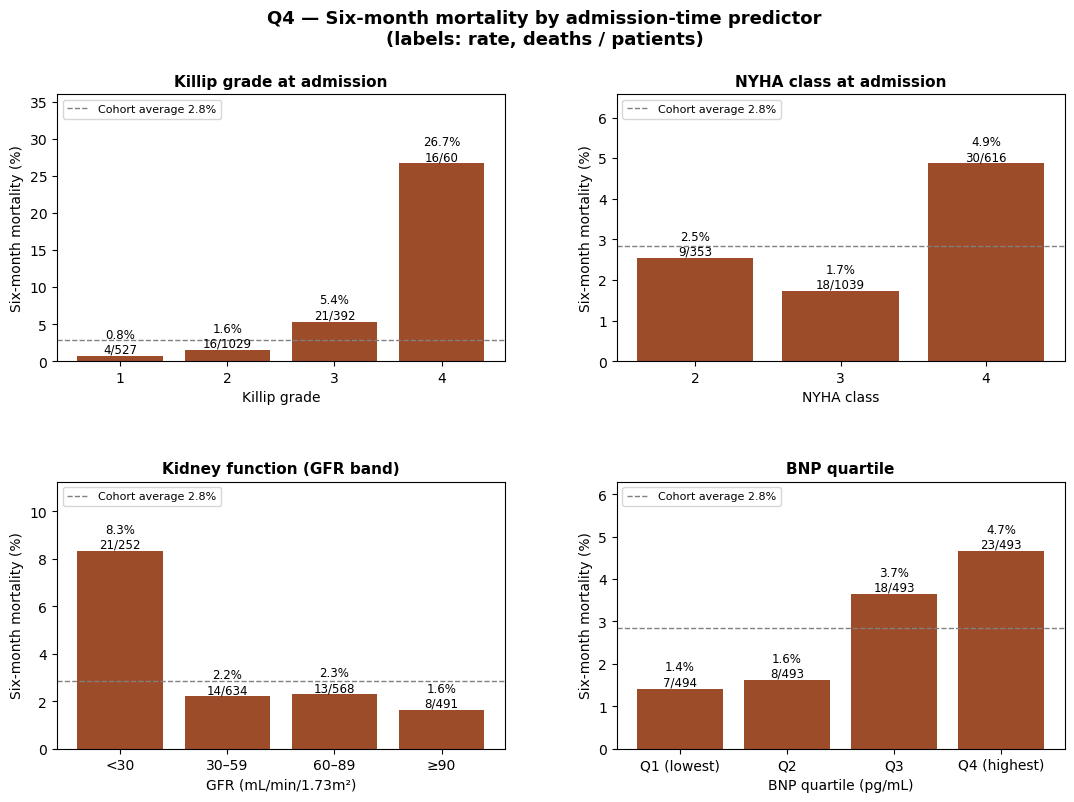

killip_grade                           0.760
glomerular_filtration_rate             0.671
brain_natriuretic_peptide              0.663
nyha_cardiac_function_classification   0.600
cci_score                              0.525
Name: single_predictor_auc, dtype: float64

In [125]:
# ============================================================
# Q4 — STEP 6: EVIDENCE OF ASSOCIATION (UNIVARIATE)
# ============================================================
q4_evidence = q4_model_df.assign(
    gfr_band=pd.cut(q4_model_df["glomerular_filtration_rate"], [0, 30, 60, 90, np.inf],
                    right=False, labels=["<30", "30–59", "60–89", "≥90"]),
    bnp_quartile=pd.qcut(q4_model_df["brain_natriuretic_peptide"], 4,
                         labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]),
)

q4_panels = [
    ("killip_grade", "Killip grade at admission", "Killip grade"),
    ("nyha_cardiac_function_classification", "NYHA class at admission", "NYHA class"),
    ("gfr_band", "Kidney function (GFR band)", "GFR (mL/min/1.73m²)"),
    ("bnp_quartile", "BNP quartile", "BNP quartile (pg/mL)"),
]

fig = plt.figure(figsize=(13, 8.5))
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.25)
q4_rate_tables = {}
for i, (col, title, xlabel) in enumerate(q4_panels):
    ax = fig.add_subplot(gs[i // 2, i % 2])
    tab = (q4_evidence.groupby(col, observed=True)[q4_target]
           .agg(patients="size", deaths="sum", rate="mean"))
    tab["rate_pct"] = tab["rate"] * 100
    q4_rate_tables[col] = tab
    bars = ax.bar(tab.index.astype(str), tab["rate_pct"], color="#8c2d04", alpha=0.85)
    ax.axhline(q4_mortality_prevalence * 100, ls="--", color="grey", lw=1,
               label=f"Cohort average {q4_mortality_prevalence:.1%}")
    for bar, (_, row) in zip(bars, tab.iterrows()):
        ax.annotate(f"{row['rate_pct']:.1f}%\n{int(row['deaths'])}/{int(row['patients'])}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=8.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Six-month mortality (%)")
    ax.set_ylim(0, tab["rate_pct"].max() * 1.35)
    ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Q4 — Six-month mortality by admission-time predictor\n(labels: rate, deaths / patients)",
             fontsize=13, fontweight="bold")
plt.show()

# Single-predictor ROC-AUC (direction-adjusted) — descriptive only, not used to choose features
q4_single_auc = pd.Series({
    f: max(a, 1 - a)
    for f in Q4_ADMISSION_FEATURES
    for a in [roc_auc_score(q4_y[q4_X[f].notna()], q4_X[f].dropna())]
}, name="single_predictor_auc").round(3).sort_values(ascending=False)
q4_single_auc

**What we found:**
- **Killip grade** has the steepest gradient (grade 4 mortality is over 30× grade 1) and is the strongest single predictor (AUC ≈ 0.76).
- **Kidney function** acts like a threshold rather than a slope: mortality is 8.3% when GFR is below 30 but around 2% in every higher band (single-predictor AUC ≈ 0.67).
- **BNP** rises steadily across quartiles, from 1.4% to 4.7% (AUC ≈ 0.66).
- **NYHA** is only elevated at class 4 (AUC ≈ 0.60). CCI on its own is weak (≈ 0.53); it stays in the model because it was pre-specified on clinical grounds, and Step 12 shows whether it contributes once the other predictors are accounted for.

**Why it matters:** each predictor carries its own signal, but they overlap (sicker hearts also strain the kidneys). The model in Step 8 tests whether combining them ranks patients better than bedside severity alone.

### Step 7 — Validation Design: Why Repeated Cross-Validation Instead of One Train/Test Split

**Why?** With 57 deaths, a 75/25 split leaves only about 14 deaths in the test set. One or two patients moving between sets can shift the ROC-AUC by several points, so any conclusion would depend on the random seed.

**How?** Repeated stratified 5-fold cross-validation, repeated 10 times (50 model fits per model):
- Stratification keeps ~11 deaths in every fold.
- In each fold, imputation, scaling and the model are fitted on the training part only, and the held-out fold is scored. Every patient is therefore scored by a model that **never saw that patient** — the same guarantee a test set gives, but using all 57 deaths for evaluation.
- We report the mean and spread across the 10 repeats, plus a bootstrap 95% confidence interval.

**Counter-argument:** a fully untouched test set is the gold standard. That is true when there are enough events; here it would give a less reliable estimate than cross-validation. Because there is no hyperparameter tuning and the features were frozen in Step 5, there is no model-selection step that could leak into the evaluation, so nested cross-validation is not needed.

In [126]:
# ============================================================
# Q4 — STEP 7: REPEATED STRATIFIED CROSS-VALIDATION SETUP
# ============================================================
q4_cv = RepeatedStratifiedKFold(n_splits=Q4_N_SPLITS, n_repeats=Q4_N_REPEATS,
                                random_state=Q4_RANDOM_STATE)
q4_splits = list(q4_cv.split(q4_X, q4_y))

q4_deaths_per_fold = pd.Series([int(q4_y[test].sum()) for _, test in q4_splits])
print(f"Total fits per model: {len(q4_splits)}")
print(f"Deaths per held-out fold: min {q4_deaths_per_fold.min()}, "
      f"max {q4_deaths_per_fold.max()}, mean {q4_deaths_per_fold.mean():.1f}")

Total fits per model: 50
Deaths per held-out fold: min 11, max 12, mean 11.4


### Step 8 — Train and Compare the Three Models

**What?** For each model and each repeat, one out-of-fold (OOF) probability per patient. Metrics:
- **ROC-AUC** — how well the model ranks a death above a survivor (0.5 = coin toss).
- **PR-AUC** — precision across recall levels; the no-skill value equals the prevalence (2.84%), so it shows performance on the rare class directly.
- **Brier score** — mean squared error of the probabilities (lower is better); compared against the prevalence baseline.

**Why logistic regression and not a random forest?** With 57 events, a flexible model has far more capacity than the data can support and would mostly learn noise. Logistic regression also gives interpretable odds ratios (Step 12).

**What we expect:** M1 clearly above M0 (Killip alone is strong); M2 modestly above M1.

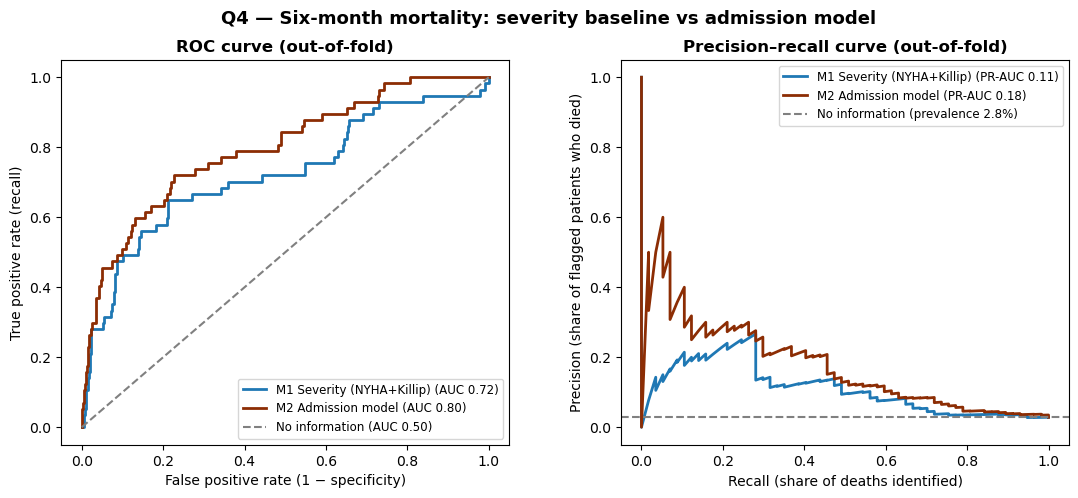

,ROC-AUC mean,ROC-AUC SD,PR-AUC mean,PR-AUC / prevalence,Brier mean,Brier skill vs M0 (%)
model,,,,,,
M0 Prevalence baseline,0.489,0.000,0.028,0.980,0.028,0.000
M1 Severity (NYHA+Killip),0.742,0.006,0.124,4.352,0.026,6.636
M2 Admission model,0.795,0.006,0.186,6.541,0.025,8.056


In [127]:
# ============================================================
# Q4 — STEP 8: CROSS-VALIDATED MODEL COMPARISON
# ============================================================
q4_oof = {name: np.zeros((Q4_N_REPEATS, len(q4_y))) for name in q4_models}

for split_no, (train_idx, test_idx) in enumerate(q4_splits):
    repeat_no = split_no // Q4_N_SPLITS
    for name, (pipeline, features) in q4_models.items():
        fitted = clone(pipeline).fit(q4_X.iloc[train_idx][features], q4_y[train_idx])
        q4_oof[name][repeat_no, test_idx] = fitted.predict_proba(q4_X.iloc[test_idx][features])[:, 1]

# One averaged OOF probability per patient (used for CIs, thresholds and calibration)
q4_oof_mean = {name: probs.mean(axis=0) for name, probs in q4_oof.items()}

q4_results = []
for name, probs in q4_oof.items():
    auc = [roc_auc_score(q4_y, p) for p in probs]
    ap  = [average_precision_score(q4_y, p) for p in probs]
    bs  = [brier_score_loss(q4_y, p) for p in probs]
    q4_results.append({
        "model": name,
        "ROC-AUC mean": np.mean(auc), "ROC-AUC SD": np.std(auc),
        "PR-AUC mean": np.mean(ap),
        "PR-AUC / prevalence": np.mean(ap) / q4_mortality_prevalence,
        "Brier mean": np.mean(bs),
    })
q4_results = pd.DataFrame(q4_results).set_index("model")
q4_brier_baseline = q4_results.loc["M0 Prevalence baseline", "Brier mean"]
q4_results["Brier skill vs M0 (%)"] = (1 - q4_results["Brier mean"] / q4_brier_baseline) * 100

# ---- ROC and PR curves (averaged OOF probabilities) ----
fig = plt.figure(figsize=(13, 5))
gs = GridSpec(1, 2, figure=fig, wspace=0.25)
ax_roc, ax_pr = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
q4_colors = {"M0 Prevalence baseline": "grey", "M1 Severity (NYHA+Killip)": "#1f78b4",
             "M2 Admission model": "#8c2d04"}
for name, p in q4_oof_mean.items():
    if name.startswith("M0"):
        continue
    fpr, tpr, _ = roc_curve(q4_y, p)
    prec, rec, _ = precision_recall_curve(q4_y, p)
    ax_roc.plot(fpr, tpr, color=q4_colors[name], lw=2,
                label=f"{name} (AUC {roc_auc_score(q4_y, p):.2f})")
    ax_pr.plot(rec, prec, color=q4_colors[name], lw=2,
               label=f"{name} (PR-AUC {average_precision_score(q4_y, p):.2f})")
ax_roc.plot([0, 1], [0, 1], ls="--", color="grey", label="No information (AUC 0.50)")
ax_pr.axhline(q4_mortality_prevalence, ls="--", color="grey",
              label=f"No information (prevalence {q4_mortality_prevalence:.1%})")
ax_roc.set(title="ROC curve (out-of-fold)", xlabel="False positive rate (1 − specificity)",
           ylabel="True positive rate (recall)")
ax_pr.set(title="Precision–recall curve (out-of-fold)", xlabel="Recall (share of deaths identified)",
          ylabel="Precision (share of flagged patients who died)")
for ax in (ax_roc, ax_pr):
    ax.legend(fontsize=8.5)
    ax.title.set_fontweight("bold")
fig.suptitle("Q4 — Six-month mortality: severity baseline vs admission model", fontsize=13, fontweight="bold")
plt.show()

q4_results.round(3)

**What we found:** the prevalence baseline sits at chance (its pooled AUC is slightly under 0.50 only because each fold predicts its own training prevalence). Bedside severity alone (M1) reaches a mean ROC-AUC of about 0.74. Adding BNP, GFR and CCI (M2) raises it to about 0.79, with PR-AUC about 6–7× the prevalence. Results are very stable across repeats (SD < 0.01). The Brier score improves on the prevalence baseline, but only modestly (≈ 8% skill) — expected when the outcome is this rare.

**Why it matters:** there is clear ranking signal, and most of it comes from bedside severity. Step 9 tests whether the improvement from M1 to M2 is larger than chance.

### Step 9 — Formal Test of H₀ and of Added Value

**Why?** "AUC > 0.5" is not a hypothesis test. We use two explicit tests:

1. **Permutation test (H₀ vs H₁):** shuffle the death labels (destroying any real link between predictors and death), rerun the cross-validation, and record the AUC. Repeating this 200 times gives the distribution of AUCs that "no information" produces. The p-value is the share of shuffled AUCs at least as high as the real one.
2. **Paired bootstrap of ΔAUC (M2 − M1):** resample patients with replacement 2,000 times and recompute both AUCs on the same resample. If the 95% interval of the difference excludes 0, the extra predictors add real value.

**What we expect:** a very small permutation p-value; a positive ΔAUC whose interval may be close to 0 because there are only 57 events.

*This is the heaviest cell in Q4 (typically 1–3 minutes).*

In [128]:
# ============================================================
# Q4 — STEP 9: PERMUTATION TEST AND BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================
q4_rng = np.random.default_rng(Q4_RANDOM_STATE)
q4_m2_pipeline, q4_m2_features = q4_models["M2 Admission model"]
q4_observed_auc = q4_results.loc["M2 Admission model", "ROC-AUC mean"]

# ---- 1. Permutation test (one 5-fold repeat per permutation to keep runtime short) ----
q4_perm_splits = q4_splits[:Q4_N_SPLITS]
q4_perm_aucs = []
for _ in range(Q4_N_PERMUTATIONS):
    y_perm = q4_rng.permutation(q4_y)
    p_perm = np.zeros(len(y_perm))
    for train_idx, test_idx in q4_perm_splits:
        fitted = clone(q4_m2_pipeline).fit(q4_X.iloc[train_idx][q4_m2_features], y_perm[train_idx])
        p_perm[test_idx] = fitted.predict_proba(q4_X.iloc[test_idx][q4_m2_features])[:, 1]
    q4_perm_aucs.append(roc_auc_score(y_perm, p_perm))
q4_perm_aucs = np.array(q4_perm_aucs)
q4_perm_p = (np.sum(q4_perm_aucs >= q4_observed_auc) + 1) / (Q4_N_PERMUTATIONS + 1)

# ---- 2. Paired bootstrap for AUC, PR-AUC and ΔAUC ----
q4_p1, q4_p2 = q4_oof_mean["M1 Severity (NYHA+Killip)"], q4_oof_mean["M2 Admission model"]
q4_boot = []
for _ in range(Q4_N_BOOTSTRAP):
    idx = q4_rng.integers(0, len(q4_y), len(q4_y))
    yb = q4_y[idx]
    if yb.sum() == 0:
        continue
    auc1, auc2 = roc_auc_score(yb, q4_p1[idx]), roc_auc_score(yb, q4_p2[idx])
    q4_boot.append({"auc_m1": auc1, "auc_m2": auc2, "delta_auc": auc2 - auc1,
                    "prauc_m2": average_precision_score(yb, q4_p2[idx])})
q4_boot = pd.DataFrame(q4_boot)

q4_ci = q4_boot.quantile([0.025, 0.975]).T
q4_ci.columns = ["CI 2.5%", "CI 97.5%"]
q4_ci.insert(0, "estimate", [
    roc_auc_score(q4_y, q4_p1), roc_auc_score(q4_y, q4_p2),
    roc_auc_score(q4_y, q4_p2) - roc_auc_score(q4_y, q4_p1),
    average_precision_score(q4_y, q4_p2),
])

print(f"Permutation test: observed M2 AUC = {q4_observed_auc:.3f}; "
      f"shuffled-label AUCs: mean {q4_perm_aucs.mean():.3f}, max {q4_perm_aucs.max():.3f}; "
      f"p = {q4_perm_p:.4f} (smallest possible with {Q4_N_PERMUTATIONS} permutations: "
      f"{1 / (Q4_N_PERMUTATIONS + 1):.4f})")
q4_ci.round(3)

Permutation test: observed M2 AUC = 0.795; shuffled-label AUCs: mean 0.479, max 0.612; p = 0.0050 (smallest possible with 200 permutations: 0.0050)


,estimate,CI 2.5%,CI 97.5%
auc_m1,0.724,0.640,0.800
auc_m2,0.797,0.731,0.860
delta_auc,0.073,0.020,0.124
prauc_m2,0.182,0.107,0.296


*Note: Step 8 averages the AUC over the 10 repeats; the bootstrap here uses each patient's probability averaged over the 10 repeats, so the point estimates differ slightly (e.g. M1 0.74 vs 0.72). Both views lead to the same conclusion.*

**What we found:** none of the 200 shuffled-label runs came close to the real AUC (shuffled AUCs average about 0.48 and never exceed 0.62), so p is at the smallest value this test can report (≈ 0.005). The admission model's AUC 95% CI is roughly 0.73–0.86 — entirely above 0.50. The M2 − M1 difference is about +0.07, with a 95% CI of roughly +0.02 to +0.12, which excludes 0 — although the lower bound is close to 0, so the size of the added value is uncertain.

**Why it matters:** both pre-specified statistical conditions are met: there is real ranking signal (H₀ rejected), and labs plus comorbidity burden add value beyond bedside severity. The wide intervals are the honest cost of having only 57 deaths.

### Step 10 — Practical Usefulness: What Happens If a Team Can Follow Up 20% of Patients?

**Why?** A 0.50 probability threshold is meaningless for a 2.8% outcome — almost nobody would be flagged. A realistic question is: *if the follow-up team has capacity to prioritise one in five patients, how many of the eventual deaths are among them?*

**How?** Flag the 20% of patients with the highest out-of-fold risk. This threshold is set by **capacity**, not by looking at the outcome, so it cannot overfit. We compare M1 and M2 at the same workload and also show 10% and 30% for sensitivity.

**What we expect:** well over 20% of deaths captured (random flagging would capture about 20%), but low precision because deaths are rare.

In [129]:
# ============================================================
# Q4 — STEP 10: CAPACITY-BASED RISK FLAGGING
# ============================================================
def q4_capacity_table(y_true, probs, share):
    cutoff = np.quantile(probs, 1 - share)
    flagged = probs >= cutoff
    captured = int(y_true[flagged].sum())
    return {
        "flag share": f"{share:.0%}",
        "patients flagged": int(flagged.sum()),
        "deaths captured": captured,
        "recall (% of 57 deaths)": captured / y_true.sum() * 100,
        "precision (% flagged who died)": captured / flagged.sum() * 100,
        "lift vs random flagging": (captured / y_true.sum()) / share,
    }

q4_capacity = pd.DataFrame([
    {"model": name, **q4_capacity_table(q4_y, q4_oof_mean[name], share)}
    for share in (0.10, Q4_FLAG_SHARE, 0.30)
    for name in ("M1 Severity (NYHA+Killip)", "M2 Admission model")
]).set_index(["flag share", "model"])
q4_capacity.round(1)

patients flagged  deaths captured  \
flag share model                                                          
10%        M1 Severity (NYHA+Killip)               201               27   
           M2 Admission model                      201               28   
20%        M1 Severity (NYHA+Killip)               402               33   
           M2 Admission model                      402               36   
30%        M1 Severity (NYHA+Killip)               603               38   
           M2 Admission model                      603               42   

                                      recall (% of 57 deaths)  \
flag share model                                                
10%        M1 Severity (NYHA+Killip)                   47.400   
           M2 Admission model                          49.100   
20%        M1 Severity (NYHA+Killip)                   57.900   
           M2 Admission model                          63.200   
30%        M1 Severity (NYHA+Killip)                   66.700   
           M2 Admission model                          73.700   

                                      precision (% flagged who died)  \
flag share model                                                       
10%        M1 Severity (NYHA+Killip)                          13.400   
           M2 Admission model                                 13.900   
20%        M1 Severity (NYHA+Killip)                           8.200   
           M2 Admission model                                  9.000   
30%        M1 Severity (NYHA+Killip)                           6.300   
           M2 Admission model                                  7.000   

                                      lift vs random flagging  
flag share model                                               
10%        M1 Severity (NYHA+Killip)                    4.700  
           M2 Admission model                           4.900  
20%        M1 Severity (NYHA+Killip)                    2.900  
           M2 Admission model                           3.200  
30%        M1 Severity (NYHA+Killip)                    2.200  
           M2 Admission model                           2.500

**What we found:** flagging the top 20% by the admission model captures 36 of 57 deaths (63%) — about 3× what random flagging would achieve — versus 33 deaths with the severity-only model. Precision stays low (about 9%): roughly 1 in 11 flagged patients dies within six months.

**Why it matters:** the model is a **prioritisation aid, not a diagnostic**. It is suitable for low-cost actions applied to a list (earlier follow-up call, medication review, goals-of-care conversation), where a low precision is acceptable. It is not suitable for high-cost or high-harm interventions triggered on individual patients.

### Step 11 — Calibration: Can the Predicted Probabilities Be Trusted as Real Risks?

**Why?** Ranking (AUC) and calibration are different. If the model says "8% risk", about 8 in 100 such patients should actually die. We deliberately did **not** use `class_weight="balanced"` (a Q2 review finding), because re-weighting inflates predicted probabilities for rare outcomes.

**How?** Group patients into five equal-sized risk groups (quintiles — ten bins would leave too few deaths per bin) and compare mean predicted risk with the observed death rate.

**What we expect:** predicted and observed rates close in every quintile.

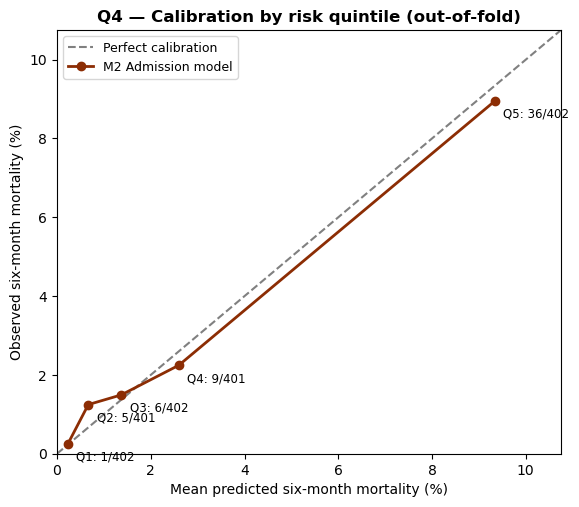

Calibration-in-the-large: mean predicted 2.84% vs observed 2.84%


,patients,deaths,mean_predicted_pct,observed_pct
risk_quintile,,,,
Q1,402,1,0.230,0.250
Q2,401,5,0.670,1.250
Q3,402,6,1.370,1.490
Q4,401,9,2.600,2.240
Q5,402,36,9.350,8.960


In [130]:
# ============================================================
# Q4 — STEP 11: CALIBRATION BY RISK QUINTILE
# ============================================================
q4_calibration = (
    pd.DataFrame({"predicted": q4_oof_mean["M2 Admission model"], "died": q4_y})
    .assign(risk_quintile=lambda t: pd.qcut(t["predicted"], 5, labels=[f"Q{i}" for i in range(1, 6)]))
    .groupby("risk_quintile", observed=True)
    .agg(patients=("died", "size"), deaths=("died", "sum"),
         mean_predicted_pct=("predicted", "mean"), observed_pct=("died", "mean"))
)
q4_calibration[["mean_predicted_pct", "observed_pct"]] *= 100

fig, ax = plt.subplots(figsize=(6.5, 5.5))
q4_lim = q4_calibration[["mean_predicted_pct", "observed_pct"]].max().max() * 1.15
ax.plot([0, q4_lim], [0, q4_lim], ls="--", color="grey", label="Perfect calibration")
ax.plot(q4_calibration["mean_predicted_pct"], q4_calibration["observed_pct"],
        marker="o", color="#8c2d04", lw=2, label="M2 Admission model")
for q, row in q4_calibration.iterrows():
    ax.annotate(f"{q}: {int(row['deaths'])}/{int(row['patients'])}",
                (row["mean_predicted_pct"], row["observed_pct"]),
                textcoords="offset points", xytext=(6, -12), fontsize=8.5)
ax.set(xlim=(0, q4_lim), ylim=(0, q4_lim),
       xlabel="Mean predicted six-month mortality (%)",
       ylabel="Observed six-month mortality (%)",
       title="Q4 — Calibration by risk quintile (out-of-fold)")
ax.title.set_fontweight("bold")
ax.legend(fontsize=9)
plt.show()

print(f"Calibration-in-the-large: mean predicted {q4_oof_mean['M2 Admission model'].mean():.2%} "
      f"vs observed {q4_mortality_prevalence:.2%}")
q4_calibration.round(2)

**What we found:** predicted and observed mortality agree closely in every quintile. The lowest-risk quintile has about 0.2% predicted and 1 death among 402 patients; the highest-risk quintile has about 9.3% predicted versus 9.0% observed, and holds 36 of the 57 deaths. Deaths are concentrated in the top fifth; the bottom 40% of patients contain only 6 deaths.

**Why it matters:** within this cohort the probabilities can be read as approximate absolute risks, and the model also identifies a large **low-risk** group, which is useful for deciding where *not* to spend intensive follow-up resources. With only 57 events, calibration in a different hospital would need to be re-checked.

### Step 12 — Which Predictors Drive the Risk? (Odds Ratios With Bootstrap CIs)

**Why?** Judges and clinicians need to see *what* the model uses, and whether each effect makes clinical sense. Coefficients are reported as odds ratios **per 1 standard deviation** (per 1 grade would not be comparable across GFR in mL/min and Killip in grades).

**How?** Fit M2 on all patients (for interpretation only — performance was already estimated out-of-fold) and bootstrap the fit 1,000 times for 95% CIs.

**Counter-argument / caution:** these are associations adjusted for the other four predictors, not causal effects. Predictors are correlated (e.g. low GFR and high BNP travel together), so individual odds ratios can shrink when a correlated partner is present.

In [131]:
# ============================================================
# Q4 — STEP 12: ADJUSTED ODDS RATIOS (INTERPRETATION ONLY)
# ============================================================
def q4_standardised_log_odds(pipeline, X, y):
    fitted = clone(pipeline).fit(X, y)
    names = fitted.named_steps["prep"].get_feature_names_out()
    names = [n.split("__", 1)[1] for n in names]
    return pd.Series(fitted.named_steps["model"].coef_[0], index=names)

q4_full_coef = q4_standardised_log_odds(q4_m2_pipeline, q4_X[q4_m2_features], q4_y)

q4_coef_boot = []
for _ in range(1000):
    idx = q4_rng.integers(0, len(q4_y), len(q4_y))
    if q4_y[idx].sum() < 5:
        continue
    q4_coef_boot.append(q4_standardised_log_odds(q4_m2_pipeline, q4_X.iloc[idx][q4_m2_features], q4_y[idx]))
q4_coef_boot = pd.DataFrame(q4_coef_boot)

q4_odds_ratios = pd.DataFrame({
    "OR per 1 SD": np.exp(q4_full_coef),
    "CI 2.5%": np.exp(q4_coef_boot.quantile(0.025)),
    "CI 97.5%": np.exp(q4_coef_boot.quantile(0.975)),
}).sort_values("OR per 1 SD", ascending=False)
q4_odds_ratios["CI excludes 1"] = (q4_odds_ratios["CI 2.5%"] > 1) | (q4_odds_ratios["CI 97.5%"] < 1)
q4_odds_ratios.index = q4_odds_ratios.index.str.replace("brain_natriuretic_peptide", "log BNP")
q4_odds_ratios.round(2)

,OR per 1 SD,CI 2.5%,CI 97.5%,CI excludes 1
killip_grade,2.730,2.090,3.770,True
log BNP,1.520,1.110,2.190,True
nyha_cardiac_function_classification,0.930,0.710,1.270,False
cci_score,0.930,0.660,1.270,False
glomerular_filtration_rate,0.540,0.320,0.800,True


**What we found:** three predictors have intervals that exclude 1. Killip grade dominates (OR ≈ 2.7 per SD, CI ≈ 2.1–3.8). Higher log BNP raises risk (OR ≈ 1.5, CI ≈ 1.1–2.2). Higher GFR lowers risk (OR ≈ 0.54 per SD, CI ≈ 0.32–0.80) — i.e. worse kidney function means higher risk. NYHA and CCI add almost nothing once the other three are in the model (OR ≈ 0.93, intervals spanning 1). For NYHA this is expected: it overlaps with Killip. For CCI it matches its weak single-predictor signal in Step 6.

**Counter-argument:** should NYHA and CCI now be dropped? No — removing them *because* they looked weak after fitting would be outcome-driven feature selection, the exact post-hoc revision the Q2 review warned about. They were pre-specified on clinical grounds and cost little. A reduced 3-predictor model is listed as a follow-up to be tested on new data, not re-tuned on this data.

**Why it matters:** the model's logic is clinically coherent: acute haemodynamic severity at presentation dominates, and kidney function adds independent information — the cardiorenal pattern also seen in Category 3.

### Step 13 — Sensitivity Check: Does the Model Only Predict In-Hospital Deaths?

**Why?** Step 3B showed that 11 deaths happened during the index stay and most deaths were early. A sceptic could argue the model only recognises patients who are already dying on arrival. If it still ranks patients among those who **left hospital alive**, it has value for post-discharge follow-up too.

**How?** Keep the out-of-fold predictions from Step 8 unchanged (no retraining) and re-evaluate them only among patients who did not die during the stay.

In [132]:
# ============================================================
# Q4 — STEP 13: SENSITIVITY — PATIENTS WHO LEFT HOSPITAL ALIVE
# ============================================================
q4_left_alive = (q4_model_df["outcome_during_hospitalization"] != "Dead").to_numpy()
q4_sensitivity = pd.DataFrame({
    "cohort": ["All patients", "Left hospital alive"],
    "patients": [len(q4_y), int(q4_left_alive.sum())],
    "deaths": [int(q4_y.sum()), int(q4_y[q4_left_alive].sum())],
    "M1 ROC-AUC": [roc_auc_score(q4_y, q4_p1), roc_auc_score(q4_y[q4_left_alive], q4_p1[q4_left_alive])],
    "M2 ROC-AUC": [roc_auc_score(q4_y, q4_p2), roc_auc_score(q4_y[q4_left_alive], q4_p2[q4_left_alive])],
}).set_index("cohort")
q4_sensitivity.round(3)

,patients,deaths,M1 ROC-AUC,M2 ROC-AUC
cohort,,,,
All patients,2008,57,0.724,0.797
Left hospital alive,1997,46,0.712,0.790


**What we found:** among patients who left hospital alive (46 later deaths), discrimination barely changes: the admission model goes from ≈ 0.80 to ≈ 0.79 and the severity model from ≈ 0.72 to ≈ 0.71. The gain from adding BNP, GFR and CCI (≈ +0.08) is the same in both cohorts.

**Why it matters:** the model is not simply recognising patients who were already dying on arrival. It ranks risk just as well for the patients the hospital can still act on after discharge, which supports using it for **discharge planning and follow-up intensity**.

### Step 14 — Hypothesis Decision (Generated From the Results Above)

The table below is built directly from the computed results, so the conclusion cannot drift from the numbers if the notebook is re-run.

In [133]:
# ============================================================
# Q4 — STEP 14: HYPOTHESIS DECISION TABLE (AUTO-GENERATED)
# ============================================================
q4_m2_ci_low = q4_ci.loc["auc_m2", "CI 2.5%"]
q4_delta_ci_low = q4_ci.loc["delta_auc", "CI 2.5%"]
q4_top = q4_capacity.loc[(f"{Q4_FLAG_SHARE:.0%}", "M2 Admission model")]

q4_decision = pd.DataFrame([
    ["Permutation p < 0.05", f"p = {q4_perm_p:.4f}", q4_perm_p < Q4_ALPHA],
    ["M2 AUC 95% CI above 0.50", f"lower bound = {q4_m2_ci_low:.3f}", q4_m2_ci_low > 0.5],
    ["ΔAUC (M2 − M1) 95% CI excludes 0", f"lower bound = {q4_delta_ci_low:+.3f}", q4_delta_ci_low > 0],
    [f"Deaths captured at {Q4_FLAG_SHARE:.0%} workload (context)",
     f"{int(q4_top['deaths captured'])}/{int(q4_y.sum())} "
     f"({q4_top['recall (% of 57 deaths)']:.0f}%), precision {q4_top['precision (% flagged who died)']:.1f}%", None],
    ["Brier skill vs prevalence (context)",
     f"{q4_results.loc['M2 Admission model', 'Brier skill vs M0 (%)']:.1f}%", None],
], columns=["criterion", "result", "met"])

q4_reject_h0 = bool(q4_decision.loc[:1, "met"].all())
print("Decision on H0:", "REJECT H0 — admission-time predictors discriminate six-month mortality"
      if q4_reject_h0 else "DO NOT REJECT H0")
print("Added value over bedside severity:", "YES" if q4_decision.loc[2, "met"] else "NOT DEMONSTRATED")
q4_decision

Decision on H0: REJECT H0 — admission-time predictors discriminate six-month mortality
Added value over bedside severity: YES


,criterion,result,met
0,Permutation p < 0.05,p = 0.0050,True
1,M2 AUC 95% CI above 0.50,lower bound = 0.731,True
2,ΔAUC (M2 − M1) 95% CI excludes 0,lower bound = +0.020,True
3,Deaths captured at 20% workload (context),"36/57 (63%), precision 9.0%",None
4,Brier skill vs prevalence (context),8.1%,None


**Decision:** we **reject H₀**. Admission-time information discriminates between patients who die within six months and those who survive, well beyond chance, and labs plus comorbidity burden add measurable value over bedside severity alone.

**How strongly we state it:** this is **internally cross-validated evidence from a single hospital**, not proof that the model would work elsewhere. The discrimination is good (AUC ≈ 0.79) and the model is well calibrated within this cohort, but precision is low because the outcome is rare. The appropriate claim is: *the model is a credible candidate for risk-based prioritisation, pending external validation* — not a ready-to-deploy clinical tool.

### Step 14B — How Q4 Relates to Q2 (28-Day Readmission)

**Why?** Q2 and Q4 use the same admission-time information to predict different outcomes. If one risk score could flag both, the hospital would only need one tool. We test whether that is true, and whether the two outcomes affect each other.

**How?**
1. **Overlap:** how often a patient is both readmitted and dead, compared with the number expected if the events were unrelated.
2. **Ranking:** apply the Q4 mortality score to the Q2 cohort (discharged alive, consistent event timing) and measure how well it ranks 28-day readmission.

**What we expect:** some overlap (sicker patients both die and return to hospital) and partial ability of the mortality score to rank readmission.

In [134]:
# ============================================================
# Q4 — STEP 14B: HOW SIX-MONTH MORTALITY RELATES TO READMISSION (Q2)
# ============================================================
# Same cohort rule as Q2: patients discharged alive with consistent event timing
q4_q2_cohort = (
    q4_model_df["outcome_during_hospitalization"].ne("Dead")
    & ~q4_model_df["event_time_contradiction_flag"].astype(bool)
).to_numpy()

# 1. Do deaths and readmissions ever co-occur in this dataset?
q4_overlap = pd.DataFrame({
    "comparison": ["28-day readmission vs 6-month death", "3-month readmission vs 3-month death", "6-month readmission vs 6-month death"],
    "readmitted": [
        int(q4_model_df["re_admission_within_28_days"].sum()),
        int(q4_model_df["re_admission_within_3_months"].sum()),
        int(q4_model_df["re_admission_within_6_months"].sum()),
    ],
    "died": [q4_deaths, int(q4_model_df["death_within_3_months"].sum()), q4_deaths],
    "both readmitted and died": [
        int(((q4_model_df["re_admission_within_28_days"] == 1) & (q4_model_df[q4_target] == 1)).sum()),
        int(((q4_model_df["re_admission_within_3_months"] == 1) & (q4_model_df["death_within_3_months"] == 1)).sum()),
        int(((q4_model_df["re_admission_within_6_months"] == 1) & (q4_model_df[q4_target] == 1)).sum()),
    ],
})
# Overlap expected if the two events were unrelated: P(readmit) x P(death) x N
q4_overlap["expected if independent"] = (
    q4_overlap["readmitted"] * q4_overlap["died"] / len(q4_model_df)
).round(1)
display(q4_overlap)

# 2. Does the Q4 mortality risk score also rank readmission risk?
q4_readmit_view = pd.DataFrame({
    "q4_mortality_risk": q4_p2[q4_q2_cohort],
    "readmit_28d": q4_model_df.loc[q4_q2_cohort, "re_admission_within_28_days"].to_numpy(),
    "died_6m": q4_y[q4_q2_cohort],
})
q4_readmit_view["mortality_risk_quintile"] = pd.qcut(
    q4_readmit_view["q4_mortality_risk"], 5, labels=[f"Q{i}" for i in range(1, 6)])

q4_by_quintile = (
    q4_readmit_view.groupby("mortality_risk_quintile", observed=True)
    .agg(patients=("readmit_28d", "size"),
         deaths_6m=("died_6m", "sum"),
         readmissions_28d=("readmit_28d", "sum"),
         readmission_28d_pct=("readmit_28d", "mean"))
    .assign(readmission_28d_pct=lambda t: (t["readmission_28d_pct"] * 100).round(1))
)
q4_risk_auc_for_readmit = roc_auc_score(q4_readmit_view["readmit_28d"], q4_readmit_view["q4_mortality_risk"])
print(f"Q2 cohort: {q4_q2_cohort.sum():,} patients")
print(f"ROC-AUC of the Q4 mortality score for 28-day readmission: {q4_risk_auc_for_readmit:.3f}")
q4_by_quintile

,comparison,readmitted,died,both readmitted and died,expected if independent
0,28-day readmission vs 6-month death,140,57,0,4.000
1,3-month readmission vs 3-month death,498,42,0,10.400
2,6-month readmission vs 6-month death,773,57,0,21.900


Q2 cohort: 1,986 patients
ROC-AUC of the Q4 mortality score for 28-day readmission: 0.574


,patients,deaths_6m,readmissions_28d,readmission_28d_pct
mortality_risk_quintile,,,,
Q1,398,1,21,5.300
Q2,397,4,17,4.300
Q3,397,5,27,6.800
Q4,397,8,41,10.300
Q5,397,27,31,7.800


**What we found:**
- **The two outcomes never overlap in this dataset.** None of the 57 patients who died within six months is flagged as readmitted at any horizon, where about 4, 10 and 22 overlaps would be expected at 28 days, 3 months and 6 months if the events were unrelated. Death and readmission behave as **competing events**: a patient who dies is never counted as readmitted. We cannot confirm from the data alone whether this reflects how events were recorded.
- **The mortality score is a poor readmission score** (ROC-AUC ≈ 0.57). 28-day readmission is highest in mortality-risk quintile 4 (≈ 10%), not in quintile 5 (≈ 8%), even though quintile 5 contains most of the deaths.
- **Mortality is much more predictable than readmission** (Q4 AUC ≈ 0.80 vs Q2 test AUC 0.62). Death in this cohort is driven by acute severity measured at admission (Killip, BNP, GFR); readmission depends more on what happens after discharge (adherence, follow-up access, social support), which this dataset does not record.

**Why it matters:**
1. The hospital **needs both models** — one score flags the wrong patients for the other outcome.
2. Q2's "not readmitted" group includes patients who died after discharge, so some apparent non-readmissions are deaths. This competing-risk limitation applies to Q1 and Q2 as well.
3. A combined dashboard view is justified by evidence: each patient should show both risks, because a patient can be high on one and low on the other.

### Step 15 — Limitations, Why It Matters, and Follow-Up

**Limitations**
1. **Only 57 deaths.** This caps the number of predictors (EPV ≈ 11) and makes the confidence intervals wide. Stronger individual effects may exist but cannot be estimated reliably here.
2. **Timing is assumed, not verified.** Labs and scores have no timestamps. If some BNP or GFR values were measured later in the stay, performance would be overstated.
3. **BNP is censored at 5,000 pg/mL** (100 patients). The model cannot distinguish very high from extremely high BNP.
4. **Simplified shapes.** GFR risk is concentrated below 30 and NYHA risk at class 4, but both enter the model as straight-line terms to protect the small event budget.
5. **Single centre, internal validation only.** Calibration and discrimination need to be checked in another hospital or a later time period before any clinical use.
6. **Deaths outside the hospital's records may be missed.** 16 deaths have no recorded event time; if some deaths after discharge were never captured, true mortality is higher than 2.84%.
7. **Associations, not causes.** The odds ratios describe which admission findings mark risk, not what would change risk if treated.

**Why it matters (the business and clinical case)**
- One in five patients, ranked on data already collected on the day of admission, contains about two-thirds of all six-month deaths.
- The bottom 40% of patients by predicted risk contain only 6 of the 57 deaths — the model identifies where intensive follow-up is least needed, which is as valuable for resource planning as finding the high-risk group.
- Discrimination holds for patients who leave hospital alive — exactly the group whose follow-up the hospital can still influence.

**Follow-up questions**
1. Does the model generalise over time? Train on admissions from 2016–2018 and test on 2019 (a temporal validation using `admission_date`).
2. Do high-risk patients by this model have different discharge prescriptions (e.g. fewer guideline therapies)? This links Q4 to the medication analysis in Category 3.
3. Would a reduced model (Killip + BNP + GFR) perform as well on new data? This must be tested on a later time period, not re-tuned on this cohort.
4. **Combined risk view (dashboard):** Step 14B shows the mortality and readmission scores rank different patients. How many patients are high-risk on both, on one only, or on neither — and what action does each group need (e.g. goals-of-care review for high mortality risk vs. discharge-support planning for high readmission risk)?

# Predictive Analysis — Overall Conclusion

## The question behind all four models
**Can information available on the day a heart-failure patient is admitted predict what happens to them next?**

We tested this on four outcomes that matter to patients and to the hospital: six-month readmission (Q1), 28-day readmission (Q2), prolonged hospital stay (Q3) and six-month mortality (Q4). Every model:
- used only admission-time predictors, with an explicit leakage exclusion list;
- was fitted inside pipelines, so no information from the evaluation patients leaked into preprocessing;
- was compared against a no-information baseline and, where relevant, a bedside-severity baseline (NYHA + Killip);
- was judged on metrics suited to its outcome rate, not on accuracy alone.

## Summary of results

| | Q1 — 6-month readmission | Q2 — 28-day readmission | Q3 — Prolonged stay (> 10 days) | Q4 — 6-month mortality |
|---|---|---|---|---|
| **Outcome rate** | 38.5% (773 patients) | 6.8% (test set) | 24.8% (498 patients) | 2.84% (57 patients) |
| **Validation** | 25% held-out test set | Held-out test set; model and threshold chosen on training data only | 5-fold cross-validation | 5-fold × 10 repeated cross-validation, bootstrap CIs, permutation test |
| **Model ROC-AUC** | 0.540 | 0.619 | 0.663 | 0.797 (95% CI 0.73–0.86) |
| **Severity-only baseline (NYHA + Killip)** | 0.515 | — | 0.545 | 0.724 |
| **Hypothesis decision** | Weak signal; not a usable screening tool | Reject H₀ — preliminary signal, limited precision (8.2%) | Reject H₀ — modest; below our pre-set 0.70 threshold | Reject H₀ — good discrimination, well calibrated; adds value over severity (ΔAUC +0.07, CI +0.02 to +0.12) |
| **Practical use** | Not recommended | Candidate discharge-planning aid, with high alert workload | Group-level bed and discharge planning | Admission-day risk prioritisation: top 20% of patients contain 63% of deaths |

*The AUCs come from different validation designs and feature sets, so they show the pattern across outcomes rather than an exact head-to-head ranking.*

## What we learned across the four questions

**1. The more acute the outcome, the better admission data predicts it.**
Performance rises steadily from six-month readmission (0.54) to 28-day readmission (0.62), prolonged stay (0.66) and six-month mortality (0.80). Most deaths in this cohort happen early (median day 4; 65% within 28 days) and are driven by how sick the patient is on arrival, which admission data captures well. Readmission depends mostly on what happens *after* discharge (medication adherence, follow-up access, social support), and none of that is recorded in this dataset. The weak readmission models are therefore a finding in themselves, not a modelling failure: **admission data alone cannot tell the hospital who will come back.**

**2. The same clinical signals recur in every model.**
- **Acute cardiac severity (Killip grade)** is the strongest single predictor of death (odds ratio ≈ 2.7 per SD) and carries signal for readmission.
- **Kidney function** appears across Q2, Q3 and Q4. Lower GFR is associated with higher readmission risk (Q2) and higher mortality risk (Q4, OR ≈ 0.54 per SD higher GFR), and renal markers contribute to prolonged-stay risk (Q3).
- **Cardiac wall stress (BNP)** adds independent mortality information (OR ≈ 1.5 per SD of log BNP).

This echoes the cardiorenal pattern identified in our Category 3 analysis: patients whose heart failure is already straining the kidneys are the ones at greatest risk.

**3. Bedside severity is a strong start, but labs add measurable value.**
NYHA + Killip alone gets surprisingly far for mortality (AUC 0.72). Adding BNP, GFR and comorbidity burden improves it significantly, and the gain holds for patients who left hospital alive, the group the hospital can still act on. For prolonged stay, severity alone is weak (0.545) and the fuller admission picture adds about +0.12.

**4. Death and readmission are competing outcomes, so the hospital needs separate tools.**
In this dataset, none of the 57 patients who died was ever recorded as readmitted, where about 22 overlaps would be expected at six months if the events were unrelated. The mortality score also ranks 28-day readmission poorly (AUC 0.57). One risk score cannot serve both purposes. It also means some "non-readmitted" patients in Q1 and Q2 are actually deaths, a limitation we state explicitly.

**5. Honest evaluation mattered more than headline numbers.**
Three of the four outcomes are imbalanced, so accuracy alone would have been misleading. We therefore:
- reported PR-AUC against prevalence, Brier score and calibration;
- set alert thresholds by capacity or on training data only, never on test results;
- fixed Q4's decision rules before looking at results;
- lowered claims where the evidence was modest (Q1, Q2, Q3) rather than overstating them.

## How the hospital could use these models together

| When | Model | Action it supports |
|---|---|---|
| **Admission day** | Q4 — mortality risk | Prioritise the highest-risk fifth for senior review, closer monitoring and early goals-of-care conversations. The lowest-risk 40% (6 of 57 deaths) can follow standard pathways. |
| **Admission day** | Q3 — prolonged-stay risk | Forecast bed demand and start discharge planning early for the higher-risk group, whose prolonged-stay rate is about twice the lower-risk group's (36% vs 17%). |
| **At discharge** | Q2 — 28-day readmission risk | Target follow-up calls and medication review, accepting that most alerts will be false positives. |
| **Not recommended** | Q1 — 6-month readmission | Too weak to act on. The signal needed probably lies in post-discharge data we do not have. |

Because Step 14B shows the mortality and readmission scores flag different patients, our dashboard presents both risks side by side for each patient rather than a single combined score.

## Limitations shared by all four models
1. **Single hospital, internal validation only.** None of the models has been tested on another hospital or a later time period.
2. **Predictor timing is assumed.** Labs and scores have no timestamps. If some were measured after admission, performance is overstated.
3. **BNP is capped at 5,000 pg/mL** (100 patients), so the most extreme values are indistinguishable.
4. **Competing outcomes.** Death prevents readmission, which blurs the readmission targets.
5. **Associations, not causes.** The models identify who is at risk, not what would lower that risk.

## Recommended next steps
1. **Temporal validation:** train on 2016–2018 admissions and test on 2019, using `admission_date`.
2. **Competing-risk modelling:** model readmission and death together rather than separately.
3. **Add post-discharge information** (follow-up attendance, discharge medications) to test whether readmission becomes predictable once it is available.
4. **External validation** in another hospital before any clinical use.

## Bottom line
**Admission-day information predicts six-month mortality well, prolonged stay modestly, and readmission weakly.** The strongest, most usable result is the mortality model: it is well calibrated, adds value beyond bedside severity, and concentrates nearly two-thirds of deaths in one fifth of patients. The weaker readmission results point the hospital to where the missing information lies: what happens after the patient goes home.